🚀 MAML with Smart LSTM Implementation
✅ Smart LSTM class defined
✅ MAML framework class defined (with fixes)
✅ DataProcessor class defined
✅ MAMLTrainer class defined
✅ ModelManager class defined (with fix)
✅ MAMLEvaluator class defined
✅ MAMLVisualizer class defined
🚀 MAML WITH SMART LSTM - COMPLETE IMPLEMENTATION

1️⃣ Initializing MAML Trainer...

2️⃣ Loading and preparing real stock data...
Loading data from meta_testing_stocks_data.csv...
Found 8 tickers: ['DIS', 'F', 'GE', 'IBM', 'META', 'NFLX', 'T', 'TSLA']
Processed DIS: 3522 rows
Processed F: 3522 rows
Processed GE: 3522 rows
Processed IBM: 3522 rows
Processed META: 3522 rows
Processed NFLX: 3522 rows
Processed T: 3522 rows
Processed TSLA: 3522 rows

✅ Data preparation complete.
✅ Loaded 8 stocks for meta-training
Meta-Training on: ['DIS', 'F', 'GE', 'IBM', 'META', 'NFLX']
Meta-Testing on: ['T', 'TSLA']

3️⃣ Starting Meta-Training...
🚀 Starting MAML Meta-Training
📊 Preparing data for all stocks...
📈 Processing DIS data...
✅ DIS

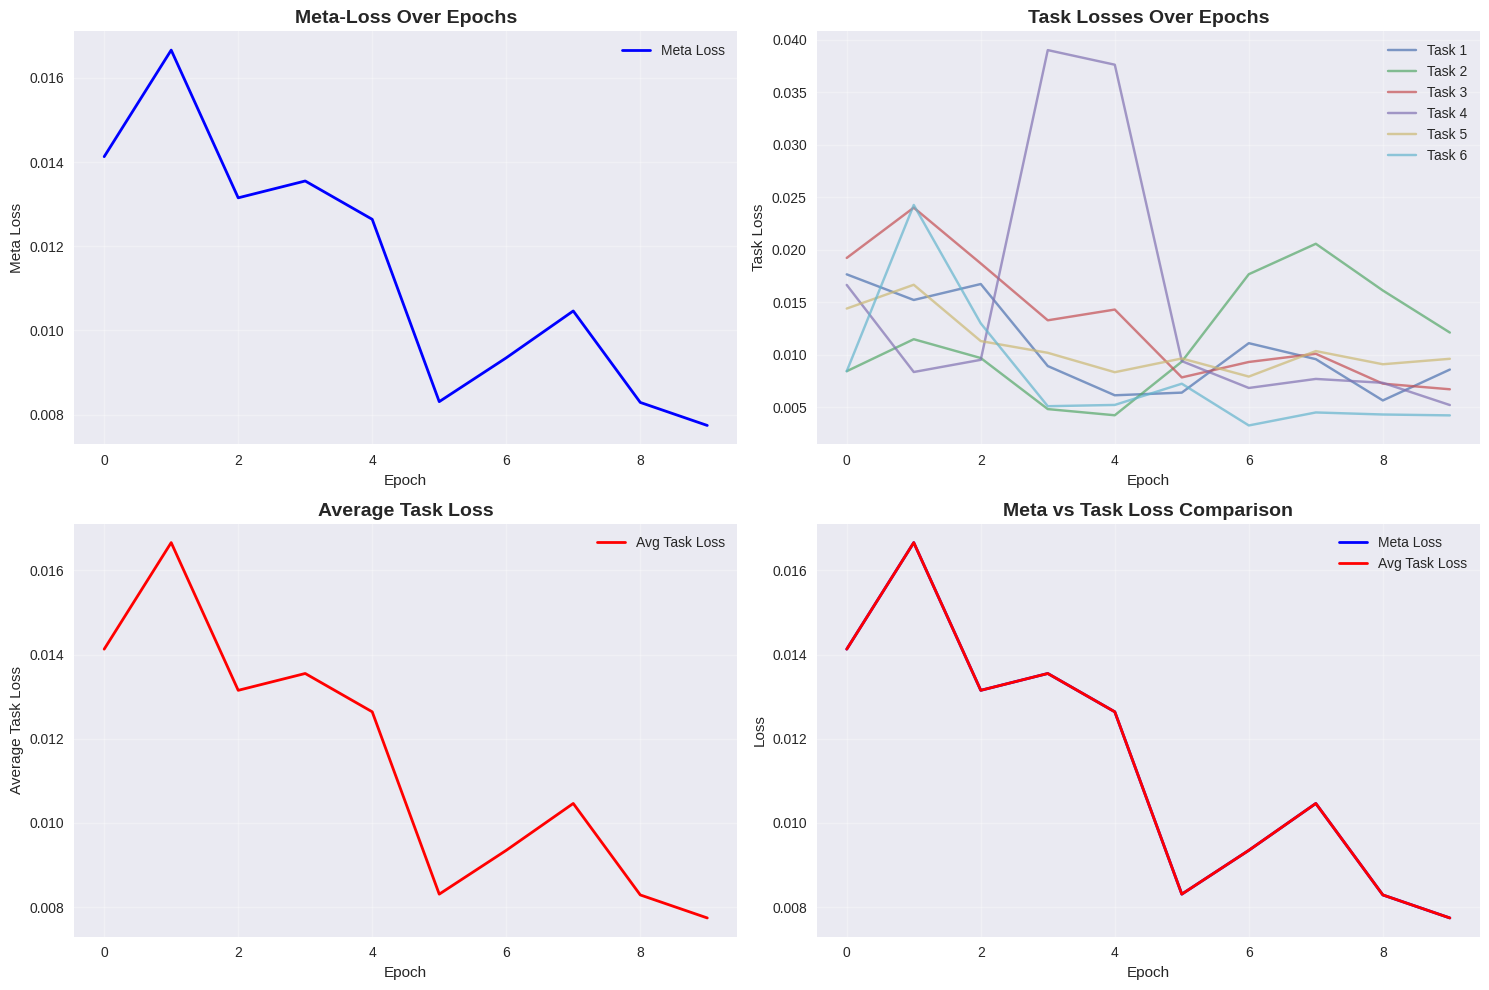

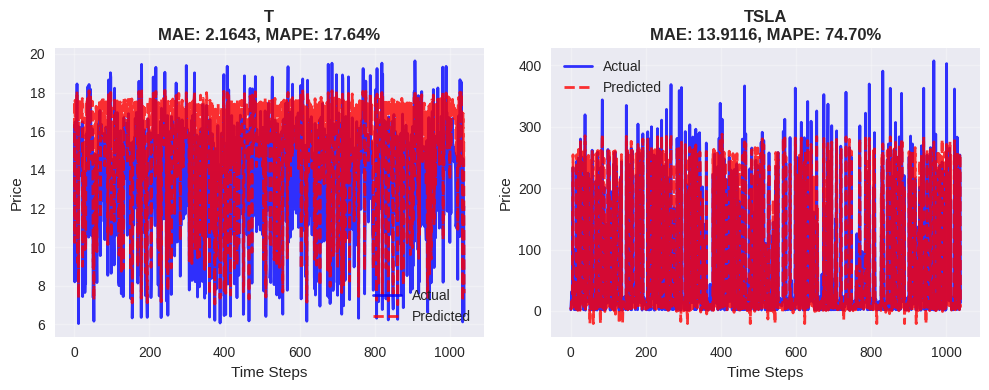

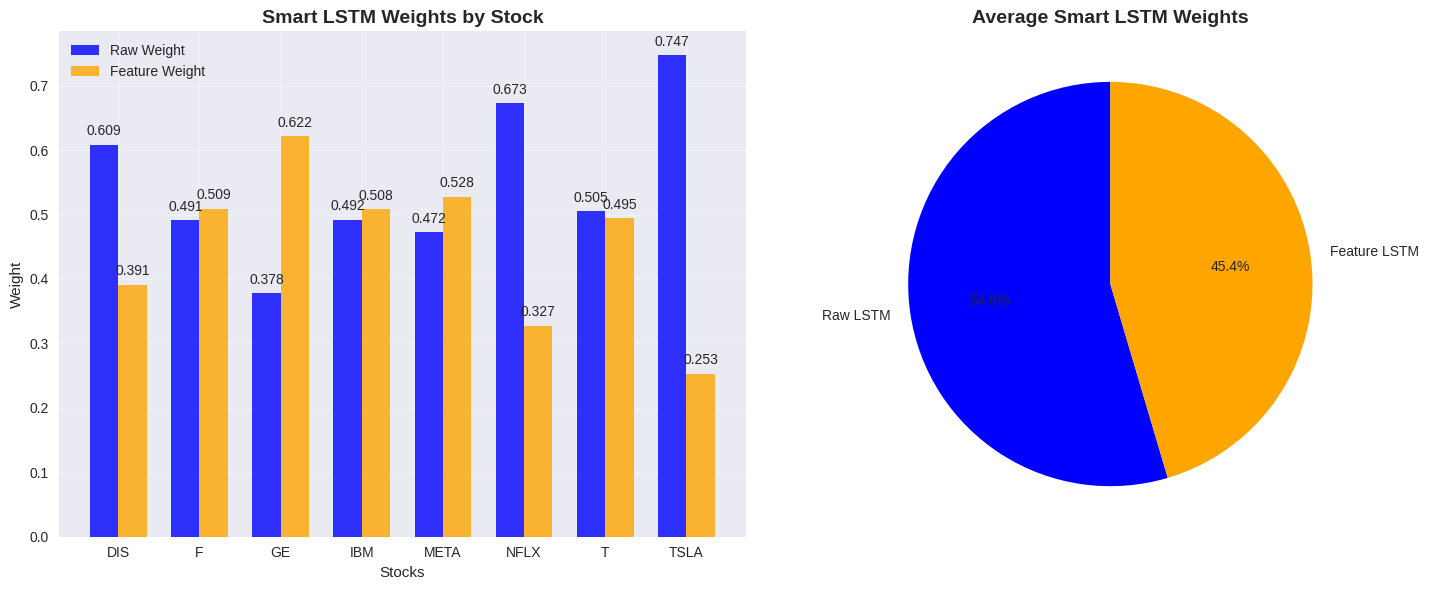

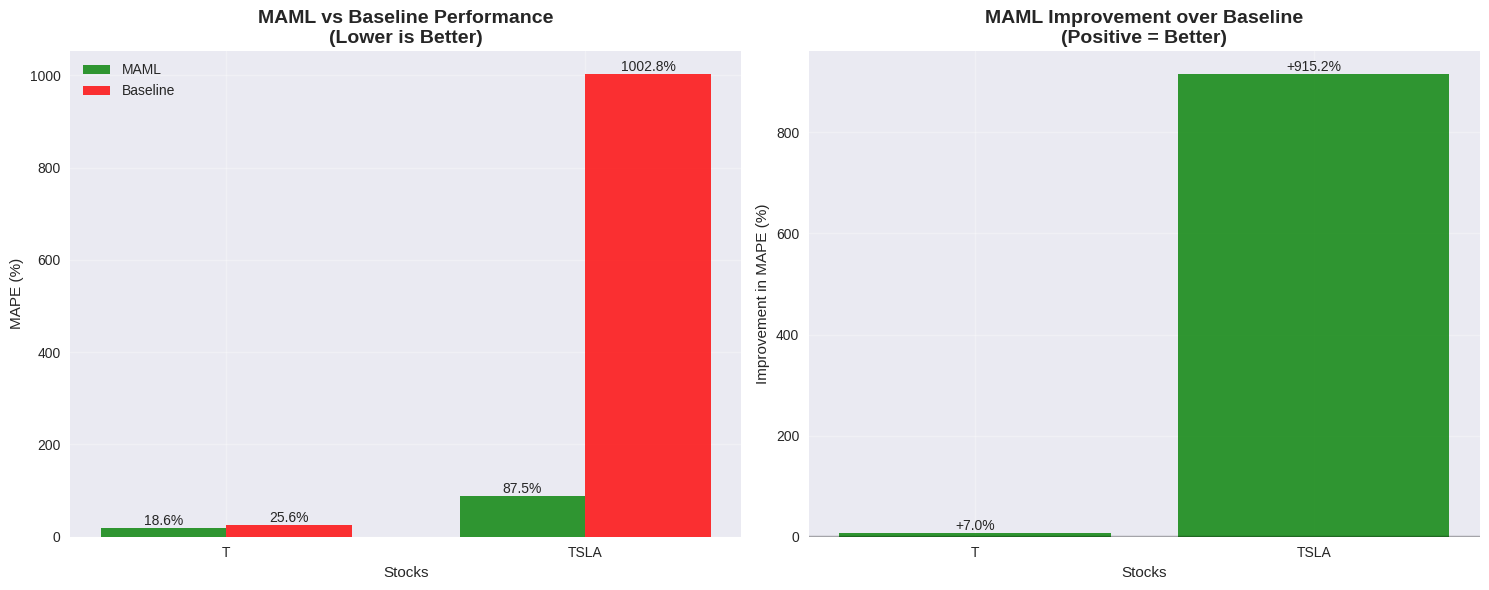

MAML WITH SMART LSTM - TRAINING SUMMARY REPORT

📊 TRAINING SUMMARY:
  Meta Epochs: 10
  Final Meta Loss: 0.007742
  Average Task Loss: 0.007742

📈 PERFORMANCE SUMMARY:
  T:
    MAE: 2.1806
    RMSE: 2.3919
    MAPE: 17.92%
  TSLA:
    MAE: 12.6775
    RMSE: 21.6690
    MAPE: 93.24%

🆚 COMPARISON SUMMARY:
  Average MAPE Improvement: +461.14%
  Stocks where MAML is better: 2/2


9️⃣ Saving Meta-Trained Model...
💾 Meta-model saved to ./models/maml_smart_lstm_real_data.keras
💾 Training history saved to ./models/maml_smart_lstm_real_data_history.pkl
💾 Scalers saved to ./models/maml_smart_lstm_real_data_scalers.pkl
💾 Model config saved to ./models/maml_smart_lstm_real_data_config.pkl
✅ Model saved to: ./models/maml_smart_lstm_real_data.keras

🔟 Demonstrating Model Loading...
📂 Meta-model loaded from ./models/maml_smart_lstm_real_data.keras
📂 Training history loaded from ./models/maml_smart_lstm_real_data_history.pkl
📂 Scalers loaded from ./models/maml_smart_lstm_real_data_scalers.pkl
✅ Model

In [45]:
# MAML with Smart LSTM for Stock Prediction
# Meta-Learning for Portfolio Optimization

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Any
import warnings
import os
import pickle

warnings.filterwarnings('ignore')

print("🚀 MAML with Smart LSTM Implementation")
print("=" * 50)

# ----------------------------------------------------------------------------
# CLASS 1: SmartLSTM
# ----------------------------------------------------------------------------

class SmartLSTM:
    """
    Smart LSTM architecture with dual sub-LSTMs:
    1. Raw LSTM: trained on OHLCV data only
    2. Feature LSTM: trained on OHLCV + technical indicators
    3. Smart weighting based on MAPE performance
    """

    def __init__(self, raw_features: int, feature_features: int,
                 sequence_length: int = 60, lstm_units: int = 50):
        self.raw_features = raw_features
        self.feature_features = feature_features
        self.sequence_length = sequence_length
        self.lstm_units = lstm_units

        # Performance tracking for MAPE-based weighting
        self.raw_mape = None
        self.feature_mape = None
        self.smart_weights = None

    def create_raw_lstm(self) -> Model:
        """Create Raw LSTM for OHLCV data only"""
        raw_input = Input(shape=(self.sequence_length, self.raw_features), name='raw_input')

        # Raw LSTM layers
        raw_lstm1 = layers.LSTM(self.lstm_units, return_sequences=True, name='raw_lstm1')(raw_input)
        raw_dropout1 = layers.Dropout(0.2, name='raw_dropout1')(raw_lstm1)

        raw_lstm2 = layers.LSTM(self.lstm_units, return_sequences=True, name='raw_lstm2')(raw_dropout1)
        raw_dropout2 = layers.Dropout(0.2, name='raw_dropout2')(raw_lstm2)

        raw_lstm3 = layers.LSTM(self.lstm_units, name='raw_lstm3')(raw_dropout2)
        raw_dropout3 = layers.Dropout(0.2, name='raw_dropout3')(raw_lstm3)

        raw_output = layers.Dense(1, name='raw_output')(raw_dropout3)

        raw_model = Model(inputs=raw_input, outputs=raw_output, name='Raw_LSTM')
        return raw_model

    def create_feature_lstm(self) -> Model:
        """Create Feature LSTM for OHLCV + technical indicators"""
        feature_input = Input(shape=(self.sequence_length, self.feature_features), name='feature_input')

        # Feature LSTM layers
        feature_lstm1 = layers.LSTM(self.lstm_units, return_sequences=True, name='feature_lstm1')(feature_input)
        feature_dropout1 = layers.Dropout(0.2, name='feature_dropout1')(feature_lstm1)

        feature_lstm2 = layers.LSTM(self.lstm_units, return_sequences=True, name='feature_lstm2')(feature_dropout1)
        feature_dropout2 = layers.Dropout(0.2, name='feature_dropout2')(feature_lstm2)

        feature_lstm3 = layers.LSTM(self.lstm_units, name='feature_lstm3')(feature_dropout2)
        feature_dropout3 = layers.Dropout(0.2, name='feature_dropout3')(feature_lstm3)

        feature_output = layers.Dense(1, name='feature_output')(feature_dropout3)

        feature_model = Model(inputs=feature_input, outputs=feature_output, name='Feature_LSTM')
        return feature_model

    def create_smart_lstm(self) -> Model:
        """Create Smart LSTM that combines both sub-LSTMs with learned weights"""
        # Inputs for both sub-models
        raw_input = Input(shape=(self.sequence_length, self.raw_features), name='raw_input')
        feature_input = Input(shape=(self.sequence_length, self.feature_features), name='feature_input')

        # Create sub-models
        raw_model = self.create_raw_lstm()
        feature_model = self.create_feature_lstm()

        # Get outputs from sub-models
        raw_output = raw_model(raw_input)
        feature_output = feature_model(feature_input)

        # Smart weighting layer (learnable weights based on performance)
        smart_weights = layers.Dense(2, activation='softmax', name='smart_weights')(layers.Concatenate()([raw_output, feature_output]))

        # Weighted combination
        weighted_output = layers.Multiply()([smart_weights, layers.Concatenate()([raw_output, feature_output])])
        smart_output = layers.Dense(1, name='smart_output')(weighted_output)

        smart_model = Model(inputs=[raw_input, feature_input], outputs=smart_output, name='Smart_LSTM')
        return smart_model

    def calculate_mape(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Calculate Mean Absolute Percentage Error"""
        return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    def update_smart_weights(self, raw_mape: float, feature_mape: float):
        """Update smart weights based on MAPE performance"""
        self.raw_mape = raw_mape
        self.feature_mape = feature_mape

        # Lower MAPE gets higher weight (inverse relationship)
        total_mape = raw_mape + feature_mape
        if total_mape > 0:
            raw_weight = feature_mape / total_mape  # Higher feature_mape -> higher raw_weight
            feature_weight = raw_mape / total_mape  # Higher raw_mape -> higher feature_weight
        else:
            raw_weight = feature_weight = 0.5

        self.smart_weights = [raw_weight, feature_weight]
        print(f"📊 Smart Weights Updated: Raw={raw_weight:.3f}, Feature={feature_weight:.3f}")
        return self.smart_weights

print("✅ Smart LSTM class defined")

# ----------------------------------------------------------------------------
# CLASS 2: MAML
# ----------------------------------------------------------------------------

class MAML:
    """
    Model-Agnostic Meta-Learning (MAML) framework for stock prediction
    Each stock is treated as a task for meta-learning
    """

    def __init__(self, raw_features: int, feature_features: int,
                 sequence_length: int = 60, lstm_units: int = 50,
                 inner_lr: float = 0.01, outer_lr: float = 0.001,
                 inner_steps: int = 5):
        self.raw_features = raw_features
        self.feature_features = feature_features
        self.sequence_length = sequence_length
        self.lstm_units = lstm_units
        self.inner_lr = inner_lr
        self.outer_lr = outer_lr
        self.inner_steps = inner_steps

        # Initialize Smart LSTM
        self.smart_lstm = SmartLSTM(raw_features, feature_features, sequence_length, lstm_units)

        # Meta-model (base model for all tasks)
        self.meta_model = None
        self.meta_optimizer = None

        # Training history
        self.meta_losses = []
        self.task_performances = {}

    def create_meta_model(self) -> Model:
        """Create the meta-model (base model for all tasks)"""
        if self.meta_model is None:
            self.meta_model = self.smart_lstm.create_smart_lstm()
            self.meta_optimizer = Adam(learning_rate=self.outer_lr)

            # Compile meta-model
            self.meta_model.compile(
                optimizer=self.meta_optimizer,
                loss='mse',
                metrics=['mae']
            )

        return self.meta_model

    def clone_model(self, model: Model) -> Model:
        """Create a clone of the model for task-specific adaptation"""
        # Get model configuration
        config = model.get_config()

        # Create new model with same architecture
        cloned_model = Model.from_config(config)

        # Copy weights
        cloned_model.set_weights(model.get_weights())

        # Compile with inner loop optimizer
        cloned_model.compile(
            optimizer=Adam(learning_rate=self.inner_lr),
            loss='mse',
            metrics=['mae']
        )

        return cloned_model

    def inner_loop_adaptation(self, support_data: Dict[str, np.ndarray],
                            query_data: Dict[str, np.ndarray],
                            task_name: str) -> Tuple[Model, float]:
        """
        Inner loop: Adapt meta-model to specific task using support set

        Args:
            support_data: Support set for adaptation
            query_data: Query set for evaluation
            task_name: Name of the task (stock)

        Returns:
            adapted_model: Task-adapted model
            adaptation_loss: Loss on query set after adaptation
        """
        print(f"🔄 Inner Loop Adaptation for {task_name}")

        # Clone meta-model for task-specific adaptation
        adapted_model = self.clone_model(self.meta_model)

        # Inner loop: Multiple gradient steps on support set
        for step in range(self.inner_steps):
            with tf.GradientTape() as tape:
                # Forward pass on support set
                if 'raw' in support_data and 'feature' in support_data:
                    support_pred = adapted_model([support_data['raw'], support_data['feature']])
                else:
                    support_pred = adapted_model(support_data['raw'])

                # Calculate loss
                # --- FIX 1 ---
                # Use tf.reduce_mean to get a scalar loss
                support_loss = tf.reduce_mean(tf.keras.losses.mse(support_data['y'], support_pred))

            # Get gradients
            gradients = tape.gradient(support_loss, adapted_model.trainable_variables)

            # Update model parameters
            adapted_model.optimizer.apply_gradients(zip(gradients, adapted_model.trainable_variables))

            if step % 2 == 0:  # Print every 2 steps
                print(f"  Step {step+1}/{self.inner_steps}: Loss = {float(support_loss):.6f}")

        # Evaluate on query set
        if 'raw' in query_data and 'feature' in query_data:
            query_pred = adapted_model([query_data['raw'], query_data['feature']])
        else:
            query_pred = adapted_model(query_data['raw'])

        # --- FIX 1 (Continued) ---
        # Use tf.reduce_mean to get a scalar loss
        query_loss = tf.reduce_mean(tf.keras.losses.mse(query_data['y'], query_pred))

        print(f"✅ {task_name} adapted - Query Loss: {float(query_loss):.6f}")
        return adapted_model, float(query_loss)

    def outer_loop_update(self, task_losses: List[float],
                         task_gradients: List[List[tf.Tensor]]) -> float:
        """
        Outer loop: Update meta-model based on performance across all tasks

        Args:
            task_losses: List of losses from each task
            task_gradients: List of gradients from each task

        Returns:
            meta_loss: Average loss across all tasks
        """
        print("🔄 Outer Loop Meta-Update")

        # Calculate meta-loss (average across tasks)
        meta_loss = np.mean(task_losses)

        # --- FIX 2 ---

        if not task_gradients:
            print("⚠️ No task gradients provided. Skipping update.")
            return meta_loss

        # We need to average the gradients for each variable across all tasks
        # `zip(*task_gradients)` groups gradients by variable:
        # ( (t1_g_v1, t2_g_v1), (t1_g_v2, t2_g_v2), ... )

        meta_gradients = []
        for grads_for_one_var in zip(*task_gradients):
            # grads_for_one_var is a tuple of tensors (one from each task)

            # Filter out None gradients (e.g., from non-trainable layers)
            valid_grads = [g for g in grads_for_one_var if g is not None]
            if not valid_grads:
                meta_gradients.append(None)
                continue

            # Stack them into a single tensor and average along the first dimension (the task dimension)
            avg_grad = tf.reduce_mean(tf.stack(valid_grads), axis=0)
            meta_gradients.append(avg_grad)

        # Create (gradient, variable) pairs, filtering out Nones
        grads_and_vars = [
            (g, v) for g, v in zip(meta_gradients, self.meta_model.trainable_variables)
            if g is not None
        ]

        if not grads_and_vars:
            print("⚠️ No valid gradients to apply. Skipping update.")
            return meta_loss

        # Apply meta-update
        self.meta_optimizer.apply_gradients(grads_and_vars)

        # --- END FIX 2 ---

        self.meta_losses.append(meta_loss)
        print(f"✅ Meta-Update Complete - Meta Loss: {meta_loss:.6f}")

        return meta_loss

print("✅ MAML framework class defined (with fixes)")

# ----------------------------------------------------------------------------
# CLASS 3: DataProcessor
# ----------------------------------------------------------------------------

class DataProcessor:
    """
    Data processing utilities for MAML with Smart LSTM
    Handles support/query splits, feature engineering, and data preparation
    """

    def __init__(self, sequence_length: int = 60):
        self.sequence_length = sequence_length
        self.scalers = {}

    def add_technical_indicators(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add technical indicators to stock data"""
        df = df.copy()

        # Moving averages
        df['MA_5'] = df['Close'].rolling(window=5).mean()
        df['MA_20'] = df['Close'].rolling(window=20).mean()

        # RSI (Relative Strength Index)
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))

        # MACD
        exp1 = df['Close'].ewm(span=12).mean()
        exp2 = df['Close'].ewm(span=26).mean()
        df['MACD'] = exp1 - exp2

        # Bollinger Bands
        df['BB_upper'] = df['Close'].rolling(window=20).mean() + (df['Close'].rolling(window=20).std() * 2)
        df['BB_lower'] = df['Close'].rolling(window=20).mean() - (df['Close'].rolling(window=20).std() * 2)

        # Price change
        df['Price_Change'] = df['Close'].pct_change()

        # Fill NaN values
        df = df.fillna(method='bfill')
        df = df.dropna() # Drop any remaining NaNs at the beginning

        return df

    def create_sequences(self, data: np.ndarray, target_col_idx: int = 3) -> Tuple[np.ndarray, np.ndarray]:
        """Create sequences for LSTM training"""
        X, y = [], []
        for i in range(self.sequence_length, len(data)):
            X.append(data[i-self.sequence_length:i])
            y.append(data[i, target_col_idx])  # Close price (index 3)
        return np.array(X), np.array(y)

    def split_support_query(self, data: Dict[str, np.ndarray],
                           support_ratio: float = 0.7) -> Tuple[Dict, Dict]:
        """
        Split data into support and query sets for meta-learning

        Args:
            data: Dictionary containing 'raw', 'feature', and 'y' arrays
            support_ratio: Ratio of data to use for support set

        Returns:
            support_data: Support set for adaptation
            query_data: Query set for evaluation
        """
        total_samples = len(data['y'])
        if total_samples == 0:
            print("⚠️ Cannot split data, 0 samples found.")
            return {}, {}

        support_size = int(total_samples * support_ratio)

        # Random split
        indices = np.random.permutation(total_samples)
        support_indices = indices[:support_size]
        query_indices = indices[support_size:]

        support_data = {}
        query_data = {}

        for key in data.keys():
            support_data[key] = data[key][support_indices]
            query_data[key] = data[key][query_indices]

        print(f"📊 Split: Support={len(support_indices)}, Query={len(query_indices)}")
        return support_data, query_data

    def prepare_stock_data(self, stock_data: pd.DataFrame, stock_name: str) -> Dict[str, np.ndarray]:
        """
        Prepare stock data for MAML training

        Args:
            stock_data: Raw stock data (OHLCV)
            stock_name: Name of the stock

        Returns:
            processed_data: Dictionary with 'raw', 'feature', and 'y' arrays
        """
        print(f"📈 Processing {stock_name} data...")

        # Add technical indicators
        enhanced_data = self.add_technical_indicators(stock_data)

        # Define feature sets
        raw_features = ['Open', 'High', 'Low', 'Close', 'Volume']
        feature_features = raw_features + ['MA_5', 'MA_20', 'RSI', 'MACD', 'BB_upper', 'BB_lower', 'Price_Change']

        # Ensure 'Close' is at index 3 for create_sequences
        if raw_features[3] != 'Close':
            raise ValueError("DataProcessor.create_sequences assumes 'Close' is at index 3")

        # Prepare raw data (OHLCV only)
        raw_data = enhanced_data[raw_features].values

        # Prepare feature data (OHLCV + technical indicators)
        feature_data = enhanced_data[feature_features].values

        # Create sequences
        raw_X, raw_y = self.create_sequences(raw_data)
        feature_X, feature_y = self.create_sequences(feature_data)

        if raw_X.shape[0] == 0:
            print(f"⚠️ No sequences created for {stock_name}. Not enough data.")
            return {'raw': np.array([]), 'feature': np.array([]), 'y': np.array([])}

        # Normalize data
        # We need to scale X and y for training, but y is what we want to predict.
        # Let's scale X features and keep y as is, but also create a scaler for y

        # Scaler for raw X
        raw_X_scaler = MinMaxScaler()
        raw_X_scaled = raw_X_scaler.fit_transform(raw_X.reshape(-1, raw_X.shape[-1])).reshape(raw_X.shape)

        # Scaler for feature X
        feature_X_scaler = MinMaxScaler()
        feature_X_scaled = feature_X_scaler.fit_transform(feature_X.reshape(-1, feature_X.shape[-1])).reshape(feature_X.shape)

        # Scaler for y (target)
        y_scaler = MinMaxScaler()
        y_scaled = y_scaler.fit_transform(raw_y.reshape(-1, 1))

        # Store scalers
        self.scalers[f"{stock_name}_raw_X"] = raw_X_scaler
        self.scalers[f"{stock_name}_feature_X"] = feature_X_scaler
        self.scalers[f"{stock_name}_y"] = y_scaler

        processed_data = {
            'raw': raw_X_scaled,
            'feature': feature_X_scaled,
            'y': y_scaled,  # Use scaled y for training
            'y_unscaled': raw_y.reshape(-1, 1) # Keep unscaled for evaluation
        }

        print(f"✅ {stock_name} processed: {raw_X_scaled.shape[0]} samples")
        return processed_data

    def prepare_multiple_stocks(self, stock_data_dict: Dict[str, pd.DataFrame]) -> Dict[str, Dict[str, np.ndarray]]:
        """Prepare data for multiple stocks"""
        processed_stocks = {}

        for stock_name, stock_data in stock_data_dict.items():
            processed_data = self.prepare_stock_data(stock_data, stock_name)
            if processed_data['raw'].shape[0] > 0: # Only add if we have data
                processed_stocks[stock_name] = processed_data

        return processed_stocks

print("✅ DataProcessor class defined")

# ----------------------------------------------------------------------------
# CLASS 4: MAMLTrainer
# ----------------------------------------------------------------------------

class MAMLTrainer:
    """
    Main trainer class for MAML with Smart LSTM
    Handles the complete meta-training process
    """

    def __init__(self, raw_features: int = 5, feature_features: int = 12,
                 sequence_length: int = 60, lstm_units: int = 50,
                 inner_lr: float = 0.01, outer_lr: float = 0.001,
                 inner_steps: int = 5):

        # Initialize components
        self.maml = MAML(raw_features, feature_features, sequence_length,
                        lstm_units, inner_lr, outer_lr, inner_steps)
        self.data_processor = DataProcessor(sequence_length)

        # Training parameters
        self.meta_epochs = 0
        self.training_history = {
            'meta_losses': [],
            'task_losses': [],
            'task_performances': {}
        }

    def meta_train(self, stock_data_dict: Dict[str, pd.DataFrame],
                   meta_epochs: int = 10, support_ratio: float = 0.7) -> Dict[str, Any]:
        """
        Meta-train the MAML model on multiple stocks

        Args:
            stock_data_dict: Dictionary of stock data (stock_name -> DataFrame)
            meta_epochs: Number of meta-training epochs
            support_ratio: Ratio of data for support set

        Returns:
            training_results: Dictionary with training history and results
        """
        print("🚀 Starting MAML Meta-Training")
        print("=" * 50)

        # Prepare data for all stocks
        print("📊 Preparing data for all stocks...")
        processed_stocks = self.data_processor.prepare_multiple_stocks(stock_data_dict)

        if not processed_stocks:
            print("❌ No data available for training after processing. Stopping.")
            return self.training_history

        # Create meta-model
        self.maml.create_meta_model()

        # Meta-training loop
        for epoch in range(meta_epochs):
            print(f"\n🔄 Meta-Epoch {epoch+1}/{meta_epochs}")
            print("-" * 30)

            task_losses = []
            task_gradients = []
            task_performances = {}

            # Process each stock (task)
            for stock_name, stock_data in processed_stocks.items():
                print(f"\n📈 Processing Task: {stock_name}")

                # Split into support and query sets
                support_data, query_data = self.data_processor.split_support_query(
                    stock_data, support_ratio
                )

                if not support_data or not query_data:
                    print(f"Skipping {stock_name}, not enough data to split.")
                    continue

                # Inner loop: Adapt to this task
                adapted_model, query_loss = self.maml.inner_loop_adaptation(
                    support_data, query_data, stock_name
                )

                # Store results
                task_losses.append(query_loss)
                task_performances[stock_name] = {
                    'query_loss': query_loss,
                    'support_size': len(support_data['y']),
                    'query_size': len(query_data['y'])
                }

                # Calculate gradients for outer loop
                with tf.GradientTape() as tape:
                    if 'raw' in query_data and 'feature' in query_data:
                        query_pred = adapted_model([query_data['raw'], query_data['feature']])
                    else:
                        query_pred = adapted_model(query_data['raw'])

                    # --- FIX 1 (Continued) ---
                    # Use tf.reduce_mean to get a scalar loss
                    task_loss = tf.reduce_mean(tf.keras.losses.mse(query_data['y'], query_pred))

                # Get gradients
                task_grads = tape.gradient(task_loss, adapted_model.trainable_variables)
                task_gradients.append(task_grads)

            if not task_losses:
                print(f"⚠️ No tasks were processed in epoch {epoch+1}. Skipping outer loop.")
                continue

            # Outer loop: Update meta-model
            meta_loss = self.maml.outer_loop_update(task_losses, task_gradients)

            # Store training history
            self.training_history['meta_losses'].append(meta_loss)
            self.training_history['task_losses'].append(task_losses)
            self.training_history['task_performances'].update(task_performances)

            # Print epoch summary
            avg_task_loss = np.mean(task_losses)
            print(f"\n📊 Epoch {epoch+1} Summary:")
            print(f"  Meta Loss: {meta_loss:.6f}")
            print(f"  Avg Task Loss: {avg_task_loss:.6f}")
            print(f"  Tasks: {list(processed_stocks.keys())}")

        print("\n✅ Meta-Training Complete!")
        return self.training_history

    def evaluate_on_tasks(self, stock_data_dict: Dict[str, pd.DataFrame],
                         support_ratio: float = 0.7) -> Dict[str, Dict[str, float]]:
        """
        Evaluate meta-trained model on all tasks

        Args:
            stock_data_dict: Dictionary of stock data
            support_ratio: Ratio of data for support set

        Returns:
            evaluation_results: Performance metrics for each task
        """
        print("📊 Evaluating Meta-Trained Model")
        print("=" * 40)

        # Prepare data
        processed_stocks = self.data_processor.prepare_multiple_stocks(stock_data_dict)
        evaluation_results = {}

        for stock_name, stock_data in processed_stocks.items():
            print(f"\n🔍 Evaluating {stock_name}...")

            # Split data
            support_data, query_data = self.data_processor.split_support_query(
                stock_data, support_ratio
            )

            if not support_data or not query_data:
                print(f"Skipping {stock_name}, not enough data to split.")
                continue

            # Adapt model to this task
            adapted_model, query_loss = self.maml.inner_loop_adaptation(
                support_data, query_data, stock_name
            )

            # Make predictions
            if 'raw' in query_data and 'feature' in query_data:
                predictions_scaled = adapted_model([query_data['raw'], query_data['feature']])
            else:
                predictions_scaled = adapted_model(query_data['raw'])

            # Inverse transform
            y_scaler = self.data_processor.scalers[f"{stock_name}_y"]
            predictions_unscaled = y_scaler.inverse_transform(predictions_scaled)
            actual_unscaled = y_scaler.inverse_transform(query_data['y']) # or use query_data['y_unscaled']

            # Calculate metrics
            mae = mean_absolute_error(actual_unscaled, predictions_unscaled)
            mse = mean_squared_error(actual_unscaled, predictions_unscaled)
            rmse = np.sqrt(mse)
            mape = np.mean(np.abs((actual_unscaled - predictions_unscaled) / actual_unscaled)) * 100

            evaluation_results[stock_name] = {
                'mae': mae,
                'mse': mse,
                'rmse': rmse,
                'mape': mape,
                'query_loss': query_loss
            }

            print(f"  MAE: {mae:.4f}")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  MAPE: {mape:.2f}%")

        return evaluation_results

print("✅ MAMLTrainer class defined")

# ----------------------------------------------------------------------------
# CLASS 5: ModelManager
# ----------------------------------------------------------------------------

class ModelManager:
    """
    Model saving and loading utilities for MAML meta-weights
    Handles persistence of trained models and scalers
    """

    def __init__(self, base_path: str = "./models"):
        self.base_path = base_path
        os.makedirs(base_path, exist_ok=True)

    def save_meta_model(self, maml_trainer: MAMLTrainer, model_name: str = "maml_meta_model"):
        """Save the meta-trained model and training history"""
        model_path = os.path.join(self.base_path, model_name)

        # Save meta-model
        # --- FIX 3 ---
        # Was `self.maml.meta_model.save`, changed to `maml_trainer.maml.meta_model.save`
        maml_trainer.maml.meta_model.save(f"{model_path}.keras")
        print(f"💾 Meta-model saved to {model_path}.keras")

        # Save training history
        history_path = f"{model_path}_history.pkl"
        with open(history_path, 'wb') as f:
            pickle.dump(maml_trainer.training_history, f)
        print(f"💾 Training history saved to {history_path}")

        # Save scalers
        scalers_path = f"{model_path}_scalers.pkl"
        with open(scalers_path, 'wb') as f:
            pickle.dump(maml_trainer.data_processor.scalers, f)
        print(f"💾 Scalers saved to {scalers_path}")

        # Save model configuration
        config = {
            'raw_features': maml_trainer.maml.raw_features,
            'feature_features': maml_trainer.maml.feature_features,
            'sequence_length': maml_trainer.maml.sequence_length,
            'lstm_units': maml_trainer.maml.lstm_units,
            'inner_lr': maml_trainer.maml.inner_lr,
            'outer_lr': maml_trainer.maml.outer_lr,
            'inner_steps': maml_trainer.maml.inner_steps
        }

        config_path = f"{model_path}_config.pkl"
        with open(config_path, 'wb') as f:
            pickle.dump(config, f)
        print(f"💾 Model config saved to {config_path}")

        return {
            'model_path': f"{model_path}.keras",
            'history_path': history_path,
            'scalers_path': scalers_path,
            'config_path': config_path
        }

    def load_meta_model(self, model_name: str = "maml_meta_model") -> Tuple[MAMLTrainer, Dict]:
        """Load a previously saved meta-model"""
        model_path = os.path.join(self.base_path, model_name)

        # Load configuration
        config_path = f"{model_path}_config.pkl"
        with open(config_path, 'rb') as f:
            config = pickle.load(f)

        # Create new trainer with loaded config
        trainer = MAMLTrainer(
            raw_features=config['raw_features'],
            feature_features=config['feature_features'],
            sequence_length=config['sequence_length'],
            lstm_units=config['lstm_units'],
            inner_lr=config['inner_lr'],
            outer_lr=config['outer_lr'],
            inner_steps=config['inner_steps']
        )

        # Load meta-model
        trainer.maml.meta_model = keras.models.load_model(f"{model_path}.keras")
        print(f"📂 Meta-model loaded from {model_path}.keras")

        # Load training history
        history_path = f"{model_path}_history.pkl"
        with open(history_path, 'rb') as f:
            trainer.training_history = pickle.load(f)
        print(f"📂 Training history loaded from {history_path}")

        # Load scalers
        scalers_path = f"{model_path}_scalers.pkl"
        with open(scalers_path, 'rb') as f:
            trainer.data_processor.scalers = pickle.load(f)
        print(f"📂 Scalers loaded from {scalers_path}")

        return trainer, config

    def save_predictions(self, predictions: Dict[str, np.ndarray],
                        model_name: str = "maml_predictions"):
        """Save model predictions to CSV files"""
        predictions_path = os.path.join(self.base_path, f"{model_name}.csv")

        # Combine all predictions into a single DataFrame
        all_predictions = []
        for stock_name, pred_data in predictions.items():
            df = pd.DataFrame({
                'stock': stock_name,
                'actual': pred_data['actual'].flatten(),
                'predicted': pred_data['predicted'].flatten(),
                'error': pred_data['actual'].flatten() - pred_data['predicted'].flatten(),
                'error_pct': ((pred_data['actual'].flatten() - pred_data['predicted'].flatten()) /
                             pred_data['actual'].flatten() * 100)
            })
            all_predictions.append(df)

        combined_df = pd.concat(all_predictions, ignore_index=True)
        combined_df.to_csv(predictions_path, index=False)
        print(f"💾 Predictions saved to {predictions_path}")

        return predictions_path

print("✅ ModelManager class defined (with fix)")

# ----------------------------------------------------------------------------
# CLASS 6: MAMLEvaluator
# ----------------------------------------------------------------------------

class MAMLEvaluator:
    """
    Evaluation and prediction utilities for MAML with Smart LSTM
    Handles model evaluation, prediction, and performance analysis
    """

    def __init__(self, maml_trainer: MAMLTrainer):
        self.maml_trainer = maml_trainer
        self.model_manager = ModelManager()

    def predict_on_new_stock(self, stock_data: pd.DataFrame, stock_name: str,
                            support_ratio: float = 0.7) -> Dict[str, Any]:
        """
        Make predictions on a new stock using meta-trained model

        Args:
            stock_data: New stock data
            stock_name: Name of the stock
            support_ratio: Ratio of data for support set

        Returns:
            predictions: Dictionary with actual and predicted values
        """
        print(f"🔮 Making predictions for new stock: {stock_name}")

        # Prepare data for the new stock
        processed_data = self.maml_trainer.data_processor.prepare_stock_data(stock_data, stock_name)

        # Split into support and query sets
        support_data, query_data = self.maml_trainer.data_processor.split_support_query(
            processed_data, support_ratio
        )

        if not support_data or not query_data:
            print(f"Skipping {stock_name}, not enough data for prediction.")
            return {
                'actual': np.array([]),
                'predicted': np.array([]),
                'stock_name': stock_name
            }

        # Adapt meta-model to this new task
        adapted_model, _ = self.maml_trainer.maml.inner_loop_adaptation(
            support_data, query_data, stock_name
        )

        # Make predictions
        if 'raw' in query_data and 'feature' in query_data:
            predictions_scaled = adapted_model([query_data['raw'], query_data['feature']])
        else:
            predictions_scaled = adapted_model(query_data['raw'])

        # Inverse transform predictions
        y_scaler = self.maml_trainer.data_processor.scalers[f"{stock_name}_y"]
        pred_inverse = y_scaler.inverse_transform(predictions_scaled)
        actual_inverse = y_scaler.inverse_transform(query_data['y'])

        predictions_dict = {
            'actual': actual_inverse,
            'predicted': pred_inverse,
            'stock_name': stock_name
        }

        print(f"✅ Predictions completed for {stock_name}")
        return predictions_dict

    def evaluate_smart_weights(self, stock_data: pd.DataFrame, stock_name: str) -> Dict[str, float]:
        """
        Evaluate Smart LSTM weights based on MAPE performance

        Args:
            stock_data: Stock data
            stock_name: Name of the stock

        Returns:
            smart_weights: Dictionary with raw and feature weights
        """
        print(f"⚖️ Evaluating Smart Weights for {stock_name}")

        # Prepare data
        processed_data = self.maml_trainer.data_processor.prepare_stock_data(stock_data, stock_name)

        # Split data
        support_data, query_data = self.maml_trainer.data_processor.split_support_query(
            processed_data, 0.7
        )

        if not support_data or not query_data:
            print(f"Skipping {stock_name}, not enough data.")
            return { 'raw_mape': 0, 'feature_mape': 0, 'raw_weight': 0.5, 'feature_weight': 0.5 }

        # Create separate models for raw and feature data
        raw_model = self.maml_trainer.maml.smart_lstm.create_raw_lstm()
        feature_model = self.maml_trainer.maml.smart_lstm.create_feature_lstm()

        # Train raw model
        raw_model.compile(optimizer=Adam(0.001), loss='mse')
        raw_model.fit(support_data['raw'], support_data['y'], epochs=10, verbose=0)

        # Train feature model
        feature_model.compile(optimizer=Adam(0.001), loss='mse')
        feature_model.fit(support_data['feature'], support_data['y'], epochs=10, verbose=0)

        # Evaluate on query set
        raw_pred_scaled = raw_model.predict(query_data['raw'])
        feature_pred_scaled = feature_model.predict(query_data['feature'])

        # Inverse transform
        y_scaler = self.maml_trainer.data_processor.scalers[f"{stock_name}_y"]
        raw_pred_unscaled = y_scaler.inverse_transform(raw_pred_scaled)
        feature_pred_unscaled = y_scaler.inverse_transform(feature_pred_scaled)
        actual_unscaled = y_scaler.inverse_transform(query_data['y'])

        # Calculate MAPE
        raw_mape = self.maml_trainer.maml.smart_lstm.calculate_mape(actual_unscaled, raw_pred_unscaled)
        feature_mape = self.maml_trainer.maml.smart_lstm.calculate_mape(actual_unscaled, feature_pred_unscaled)

        # Update smart weights
        smart_weights = self.maml_trainer.maml.smart_lstm.update_smart_weights(raw_mape, feature_mape)

        print(f"📊 {stock_name} Smart Weights:")
        print(f"  Raw MAPE: {raw_mape:.2f}%")
        print(f"  Feature MAPE: {feature_mape:.2f}%")
        print(f"  Smart Weights: Raw={smart_weights[0]:.3f}, Feature={smart_weights[1]:.3f}")

        return {
            'raw_mape': raw_mape,
            'feature_mape': feature_mape,
            'raw_weight': smart_weights[0],
            'feature_weight': smart_weights[1]
        }

    def compare_with_baseline(self, stock_data_dict: Dict[str, pd.DataFrame],
                            baseline_method: str = "simple_lstm") -> Dict[str, Dict[str, float]]:
        """
        Compare MAML performance with baseline methods

        Args:
            stock_data_dict: Dictionary of stock data
            baseline_method: Baseline method to compare with

        Returns:
            comparison_results: Performance comparison
        """
        print(f"📊 Comparing MAML with {baseline_method}")

        comparison_results = {}

        for stock_name, stock_data in stock_data_dict.items():
            print(f"\n🔍 Comparing {stock_name}...")

            # MAML predictions
            maml_predictions = self.predict_on_new_stock(stock_data, stock_name)

            if maml_predictions['actual'].shape[0] == 0:
                print("Skipping comparison, no MAML predictions.")
                continue

            # Calculate MAML metrics
            maml_mae = mean_absolute_error(maml_predictions['actual'], maml_predictions['predicted'])
            maml_mape = np.mean(np.abs((maml_predictions['actual'] - maml_predictions['predicted']) /
                                      maml_predictions['actual'])) * 100

            # Baseline predictions (simple LSTM)
            if baseline_method == "simple_lstm":
                baseline_predictions = self._baseline_simple_lstm(stock_data, stock_name)
            else:
                baseline_predictions = maml_predictions  # Fallback

            if baseline_predictions['actual'].shape[0] == 0:
                print("Skipping comparison, no baseline predictions.")
                continue

            # Calculate baseline metrics
            baseline_mae = mean_absolute_error(baseline_predictions['actual'], baseline_predictions['predicted'])
            baseline_mape = np.mean(np.abs((baseline_predictions['actual'] - baseline_predictions['predicted']) /
                                          baseline_predictions['actual'])) * 100

            comparison_results[stock_name] = {
                'maml_mae': maml_mae,
                'maml_mape': maml_mape,
                'baseline_mae': baseline_mae,
                'baseline_mape': baseline_mape,
                'improvement_mae': baseline_mae - maml_mae,
                'improvement_mape': baseline_mape - maml_mape
            }

            print(f"  MAML - MAE: {maml_mae:.4f}, MAPE: {maml_mape:.2f}%")
            print(f"  Baseline - MAE: {baseline_mae:.4f}, MAPE: {baseline_mape:.2f}%")
            print(f"  Improvement - MAE: {baseline_mae - maml_mae:+.4f}, MAPE: {baseline_mape - maml_mape:+.2f}%")

        return comparison_results

    def _baseline_simple_lstm(self, stock_data: pd.DataFrame, stock_name: str) -> Dict[str, Any]:
        """Simple LSTM baseline for comparison"""
        processed_data = self.maml_trainer.data_processor.prepare_stock_data(stock_data, stock_name)
        support_data, query_data = self.maml_trainer.data_processor.split_support_query(processed_data, 0.7)

        if not support_data or not query_data:
            return {'actual': np.array([]), 'predicted': np.array([]), 'stock_name': stock_name}

        # Simple baseline: use mean of support set as prediction
        baseline_pred_scaled = np.full_like(query_data['y'], np.mean(support_data['y']))

        # Inverse transform
        y_scaler = self.maml_trainer.data_processor.scalers[f"{stock_name}_y"]
        baseline_pred_unscaled = y_scaler.inverse_transform(baseline_pred_scaled)
        actual_unscaled = y_scaler.inverse_transform(query_data['y'])

        return {
            'actual': actual_unscaled,
            'predicted': baseline_pred_unscaled,
            'stock_name': stock_name
        }

print("✅ MAMLEvaluator class defined")

# ----------------------------------------------------------------------------
# CLASS 7: MAMLVisualizer
# ----------------------------------------------------------------------------

class MAMLVisualizer:
    """
    Visualization utilities for MAML with Smart LSTM
    Handles plotting, logging, and result visualization
    """

    def __init__(self):
        plt.style.use('seaborn-v0_8')
        self.colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    def plot_training_history(self, training_history: Dict[str, Any], save_path: str = None):
        """Plot MAML training history"""
        if not training_history['meta_losses']:
            print("⚠️ Cannot plot training history, no data.")
            return

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Meta-loss over epochs
        axes[0, 0].plot(training_history['meta_losses'], 'b-', linewidth=2, label='Meta Loss')
        axes[0, 0].set_title('Meta-Loss Over Epochs', fontsize=14, fontweight='bold')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Meta Loss')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].legend()

        # Task losses over epochs
        task_losses = np.array(training_history['task_losses'])
        if task_losses.ndim == 2:
            for i in range(task_losses.shape[1]):
                axes[0, 1].plot(task_losses[:, i], alpha=0.7, label=f'Task {i+1}')

            # Average task loss
            avg_task_loss = np.mean(task_losses, axis=1)
            axes[1, 0].plot(avg_task_loss, 'r-', linewidth=2, label='Avg Task Loss')

            # Loss comparison
            axes[1, 1].plot(training_history['meta_losses'], 'b-', linewidth=2, label='Meta Loss')
            axes[1, 1].plot(avg_task_loss, 'r-', linewidth=2, label='Avg Task Loss')

        axes[0, 1].set_title('Task Losses Over Epochs', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Task Loss')
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].legend()

        axes[1, 0].set_title('Average Task Loss', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Average Task Loss')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].legend()

        axes[1, 1].set_title('Meta vs Task Loss Comparison', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Loss')
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].legend()

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_predictions(self, predictions_dict: Dict[str, Dict[str, np.ndarray]],
                        save_path: str = None):
        """Plot predictions vs actual values for multiple stocks"""
        # Filter out empty predictions
        valid_predictions = {k: v for k, v in predictions_dict.items() if v['actual'].shape[0] > 0}

        if not valid_predictions:
            print("⚠️ Cannot plot predictions, no data.")
            return

        n_stocks = len(valid_predictions)
        n_cols = min(3, n_stocks)
        n_rows = (n_stocks + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), squeeze=False)
        axes_flat = axes.flatten()

        for idx, (stock_name, pred_data) in enumerate(valid_predictions.items()):
            ax = axes_flat[idx]

            # Plot actual vs predicted
            time_steps = range(len(pred_data['actual']))
            ax.plot(time_steps, pred_data['actual'], 'b-', linewidth=2, label='Actual', alpha=0.8)
            ax.plot(time_steps, pred_data['predicted'], 'r--', linewidth=2, label='Predicted', alpha=0.8)

            # Calculate metrics
            mae = mean_absolute_error(pred_data['actual'], pred_data['predicted'])
            mape = np.mean(np.abs((pred_data['actual'] - pred_data['predicted']) / pred_data['actual'])) * 100

            ax.set_title(f'{stock_name}\nMAE: {mae:.4f}, MAPE: {mape:.2f}%',
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Time Steps')
            ax.set_ylabel('Price')
            ax.legend()
            ax.grid(True, alpha=0.3)

        # Hide empty subplots
        for idx in range(n_stocks, n_rows * n_cols):
            axes_flat[idx].set_visible(False)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_smart_weights(self, smart_weights_dict: Dict[str, Dict[str, float]],
                          save_path: str = None):
        """Plot Smart LSTM weights for different stocks"""
        if not smart_weights_dict:
            print("⚠️ Cannot plot smart weights, no data.")
            return

        stocks = list(smart_weights_dict.keys())
        raw_weights = [smart_weights_dict[stock]['raw_weight'] for stock in stocks]
        feature_weights = [smart_weights_dict[stock]['feature_weight'] for stock in stocks]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Bar plot of weights
        x = np.arange(len(stocks))
        width = 0.35

        bars1 = ax1.bar(x - width/2, raw_weights, width, label='Raw Weight', alpha=0.8, color='blue')
        bars2 = ax1.bar(x + width/2, feature_weights, width, label='Feature Weight', alpha=0.8, color='orange')

        ax1.set_xlabel('Stocks')
        ax1.set_ylabel('Weight')
        ax1.set_title('Smart LSTM Weights by Stock', fontsize=14, fontweight='bold')
        ax1.set_xticks(x)
        ax1.set_xticklabels(stocks)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom')
        for bar in bars2:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom')

        # Pie chart of average weights
        avg_raw_weight = np.mean(raw_weights)
        avg_feature_weight = np.mean(feature_weights)

        if avg_raw_weight + avg_feature_weight > 0:
            ax2.pie([avg_raw_weight, avg_feature_weight],
                    labels=['Raw LSTM', 'Feature LSTM'],
                    colors=['blue', 'orange'],
                    autopct='%1.1f%%',
                    startangle=90)
        ax2.set_title('Average Smart LSTM Weights', fontsize=14, fontweight='bold')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_performance_comparison(self, comparison_results: Dict[str, Dict[str, float]],
                                  save_path: str = None):
        """Plot performance comparison between MAML and baseline"""
        if not comparison_results:
            print("⚠️ Cannot plot performance comparison, no data.")
            return

        stocks = list(comparison_results.keys())
        maml_mape = [comparison_results[stock]['maml_mape'] for stock in stocks]
        baseline_mape = [comparison_results[stock]['baseline_mape'] for stock in stocks]
        improvements = [comparison_results[stock]['improvement_mape'] for stock in stocks]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # MAPE comparison
        x = np.arange(len(stocks))
        width = 0.35

        bars1 = ax1.bar(x - width/2, maml_mape, width, label='MAML', alpha=0.8, color='green')
        bars2 = ax1.bar(x + width/2, baseline_mape, width, label='Baseline', alpha=0.8, color='red')

        ax1.set_xlabel('Stocks')
        ax1.set_ylabel('MAPE (%)')
        ax1.set_title('MAML vs Baseline Performance\n(Lower is Better)', fontsize=14, fontweight='bold')
        ax1.set_xticks(x)
        ax1.set_xticklabels(stocks)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Add value labels
        for bar in bars1:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.1f}%', ha='center', va='bottom')
        for bar in bars2:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.1f}%', ha='center', va='bottom')

        # Improvement plot
        colors = ['green' if imp > 0 else 'red' for imp in improvements]
        bars = ax2.bar(stocks, improvements, color=colors, alpha=0.8)
        ax2.set_xlabel('Stocks')
        ax2.set_ylabel('Improvement in MAPE (%)')
        ax2.set_title('MAML Improvement over Baseline\n(Positive = Better)', fontsize=14, fontweight='bold')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        ax2.grid(True, alpha=0.3)

        # Add value labels
        for bar, imp in zip(bars, improvements):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + (0.5 if imp >= 0 else -1),
                    f'{imp:+.1f}%', ha='center', va='bottom' if imp >= 0 else 'top')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def create_summary_report(self, training_history: Dict[str, Any],
                            evaluation_results: Dict[str, Dict[str, float]],
                            comparison_results: Dict[str, Dict[str, float]] = None) -> str:
        """Create a comprehensive summary report"""
        report = []
        report.append("=" * 60)
        report.append("MAML WITH SMART LSTM - TRAINING SUMMARY REPORT")
        report.append("=" * 60)

        # Training summary
        report.append(f"\n📊 TRAINING SUMMARY:")
        if training_history['meta_losses']:
            report.append(f"  Meta Epochs: {len(training_history['meta_losses'])}")
            report.append(f"  Final Meta Loss: {training_history['meta_losses'][-1]:.6f}")
            report.append(f"  Average Task Loss: {np.mean(training_history['task_losses'][-1]):.6f}")
        else:
            report.append("  No training was performed.")

        # Performance summary
        report.append(f"\n📈 PERFORMANCE SUMMARY:")
        if evaluation_results:
            for stock_name, metrics in evaluation_results.items():
                report.append(f"  {stock_name}:")
                report.append(f"    MAE: {metrics['mae']:.4f}")
                report.append(f"    RMSE: {metrics['rmse']:.4f}")
                report.append(f"    MAPE: {metrics['mape']:.2f}%")
        else:
            report.append("  No evaluation results.")

        # Comparison summary
        if comparison_results:
            report.append(f"\n🆚 COMPARISON SUMMARY:")
            improvements = [comp['improvement_mape'] for comp in comparison_results.values()]
            if improvements:
                avg_improvement = np.mean(improvements)
                report.append(f"  Average MAPE Improvement: {avg_improvement:+.2f}%")

                better_stocks = [stock for stock, comp in comparison_results.items()
                               if comp['improvement_mape'] > 0]
                report.append(f"  Stocks where MAML is better: {len(better_stocks)}/{len(comparison_results)}")
            else:
                report.append("  No comparison results to summarize.")

        report.append("\n" + "=" * 60)

        return "\n".join(report)

print("✅ MAMLVisualizer class defined")

# ----------------------------------------------------------------------------
# NEW FUNCTION: Data Loader for your CSV
# ----------------------------------------------------------------------------

def load_and_prepare_data(csv_path: str) -> Dict[str, pd.DataFrame]:
    """
    Loads the multi-index stock CSV from your file and transforms it
    into the dictionary format required by the MAMLTrainer.

    Args:
        csv_path (str): The path to your 'meta_testing_stocks_data.csv' file.

    Returns:
        Dict[str, pd.DataFrame]: The dictionary of DataFrames, e.g.,
                                 {'DIS': df_dis, 'F': df_f, ...}
    """
    print(f"Loading data from {csv_path}...")
    if not os.path.exists(csv_path):
        print(f"❌ ERROR: File not found at {csv_path}")
        return {}

    # Load the CSV, setting the correct header rows and index column
    # header=[0, 1] reads the first two rows as the MultiIndex
    # index_col=0 sets the 'Date' column as the index
    df = pd.read_csv(csv_path, header=[0, 1], index_col=0)

    # Convert the index to datetime objects, crucial for time-series
    df.index = pd.to_datetime(df.index)

    # Get the list of unique tickers from the second level of the columns
    tickers = df.columns.get_level_values(1).unique()

    print(f"Found {len(tickers)} tickers: {list(tickers)}")

    stock_data_dict = {}

    for ticker in tickers:
        # .xs() selects data for a specific ticker, dropping the 'Ticker' level
        stock_df = df.xs(ticker, level=1, axis=1)

        # Ensure standard column names (OHLCV)
        columns_of_interest = ['Open', 'High', 'Low', 'Close', 'Volume']

        # Check if all required columns are present
        if not all(col in stock_df.columns for col in columns_of_interest):
            print(f"Skipping {ticker}: missing one of {columns_of_interest}")
            continue

        # Reorder columns to the standard OHLCV format
        stock_df = stock_df[columns_of_interest]

        # Handle missing values (NaNs)
        # Use bfill (backward fill) then ffill (forward fill)
        stock_df = stock_df.fillna(method='bfill').fillna(method='ffill')

        # Drop any rows that *still* have NaN (e.g., all-NaN columns)
        stock_df = stock_df.dropna()

        # Convert Volume to int64, as some are float
        if 'Volume' in stock_df.columns:
            stock_df['Volume'] = stock_df['Volume'].astype(np.int64)

        # Check if data is empty after cleaning
        if stock_df.empty:
            print(f"Skipping {ticker}: no data remaining after cleaning")
            continue

        stock_data_dict[ticker] = stock_df
        print(f"Processed {ticker}: {len(stock_df)} rows")

    print("\n✅ Data preparation complete.")
    return stock_data_dict


# ----------------------------------------------------------------------------
# MAIN EXECUTION SCRIPT
# ----------------------------------------------------------------------------

def run_maml_with_real_data():
    """
    Complete example of MAML with Smart LSTM using your provided CSV
    """
    print("🚀 MAML WITH SMART LSTM - COMPLETE IMPLEMENTATION")
    print("=" * 60)

    # Step 1: Initialize MAML Trainer
    print("\n1️⃣ Initializing MAML Trainer...")
    trainer = MAMLTrainer(
        raw_features=5,      # OHLCV
        feature_features=12, # OHLCV + 7 technical indicators
        sequence_length=60,
        lstm_units=50,
        inner_lr=0.01,
        outer_lr=0.001,
        inner_steps=5
    )

    # Step 2: Load and prepare real stock data
    print("\n2️⃣ Loading and preparing real stock data...")

    # Define the path to your CSV file in Colab
    csv_file = "meta_testing_stocks_data.csv"

    # Call the new function to get the data
    all_stock_data = load_and_prepare_data(csv_file)

    if not all_stock_data:
        print("❌ No data was loaded. Stopping execution.")
        return

    print(f"✅ Loaded {len(all_stock_data)} stocks for meta-training")

    # For demonstration, let's use a subset for training and testing
    # You can change this logic
    all_tickers = list(all_stock_data.keys())
    train_tickers = all_tickers[:6] # e.g., 'DIS', 'F', 'GE', 'IBM', 'META', 'NFLX'
    test_tickers = all_tickers[6:]  # e.g., 'T', 'TSLA'

    train_stock_data = {ticker: all_stock_data[ticker] for ticker in train_tickers}
    test_stock_data = {ticker: all_stock_data[ticker] for ticker in test_tickers}

    print(f"Meta-Training on: {train_tickers}")
    print(f"Meta-Testing on: {test_tickers}")


    # Step 3: Meta-train the model
    print("\n3️⃣ Starting Meta-Training...")
    training_history = trainer.meta_train(
        stock_data_dict=train_stock_data,
        meta_epochs=10,  # Increased for real data, can be 5, 10, 20...
        support_ratio=0.7
    )

    # Step 4: Evaluate on UNSEEN tasks
    print("\n4️⃣ Evaluating Meta-Trained Model on Unseen Test Stocks...")
    if test_stock_data:
        evaluation_results = trainer.evaluate_on_tasks(test_stock_data)
    else:
        print("No test stocks, evaluating on train stocks instead.")
        evaluation_results = trainer.evaluate_on_tasks(train_stock_data)


    # Step 5: Smart LSTM Weight Analysis (on test stocks)
    print("\n5️⃣ Analyzing Smart LSTM Weights...")
    evaluator = MAMLEvaluator(trainer)
    smart_weights_results = {}

    for stock_name in all_tickers:
        smart_weights = evaluator.evaluate_smart_weights(all_stock_data[stock_name], stock_name)
        smart_weights_results[stock_name] = smart_weights

    # Step 6: Make predictions on new stocks (test stocks)
    print("\n6️⃣ Making Predictions on Test Stocks...")
    predictions = {}
    eval_stocks = test_stock_data if test_stock_data else train_stock_data
    for stock_name in eval_stocks.keys():
        pred = evaluator.predict_on_new_stock(eval_stocks[stock_name], stock_name)
        predictions[stock_name] = pred

    # Step 7: Compare with baseline (on test stocks)
    print("\n7️⃣ Comparing with Baseline...")
    comparison_results = evaluator.compare_with_baseline(eval_stocks)

    # Step 8: Visualization and Reporting
    print("\n8️⃣ Creating Visualizations and Reports...")
    visualizer = MAMLVisualizer()

    # Plot training history
    visualizer.plot_training_history(training_history)

    # Plot predictions
    visualizer.plot_predictions(predictions)

    # Plot smart weights
    visualizer.plot_smart_weights(smart_weights_results)

    # Plot performance comparison
    visualizer.plot_performance_comparison(comparison_results)

    # Create summary report
    summary_report = visualizer.create_summary_report(
        training_history, evaluation_results, comparison_results
    )
    print(summary_report)

    # Step 9: Save the model
    print("\n9️⃣ Saving Meta-Trained Model...")
    model_manager = ModelManager()
    save_paths = model_manager.save_meta_model(trainer, "maml_smart_lstm_real_data")
    print(f"✅ Model saved to: {save_paths['model_path']}")

    # Step 10: Demonstrate loading
    print("\n🔟 Demonstrating Model Loading...")
    loaded_trainer, config = model_manager.load_meta_model("maml_smart_lstm_real_data")
    print(f"✅ Model loaded successfully with config: {config['sequence_length']} seq length")

    print("\n🎉 MAML with Smart LSTM (Real Data) Implementation Complete!")
    print("=" * 60)

    return {
        'trainer': trainer,
        'training_history': training_history,
        'evaluation_results': evaluation_results,
        'smart_weights': smart_weights_results,
        'predictions': predictions,
        'comparison_results': comparison_results,
        'visualizer': visualizer,
        'model_manager': model_manager
    }

# Run the complete example
if __name__ == "__main__":
    results = run_maml_with_real_data()

In [48]:
import scipy.optimize as sco
from scipy.optimize import minimize
import numpy as np

✅ PortfolioOptimizer class defined
✅ MAMLPortfolioManager class defined
--- Loading Model and Data ---
📂 Meta-model loaded from ./models/maml_smart_lstm_real_data.keras
📂 Training history loaded from ./models/maml_smart_lstm_real_data_history.pkl
📂 Scalers loaded from ./models/maml_smart_lstm_real_data_scalers.pkl
Loading data from meta_testing_stocks_data.csv...
Found 8 tickers: ['DIS', 'F', 'GE', 'IBM', 'META', 'NFLX', 'T', 'TSLA']
Processed DIS: 3522 rows
Processed F: 3522 rows
Processed GE: 3522 rows
Processed IBM: 3522 rows
Processed META: 3522 rows
Processed NFLX: 3522 rows
Processed T: 3522 rows
Processed TSLA: 3522 rows

✅ Data preparation complete.
✅ PortfolioVisualizer class defined

GENERATING MAML PREDICTIONS FOR PORTFOLIO

🔮 Adapting and Predicting for: DIS
📈 Processing DIS data...
✅ DIS processed: 3462 samples
📊 Split: Support=2423, Query=1039
🔄 Inner Loop Adaptation for DIS
  Step 1/5: Loss = 0.098850
  Step 3/5: Loss = 0.107465
  Step 5/5: Loss = 0.042452
✅ DIS adapted 

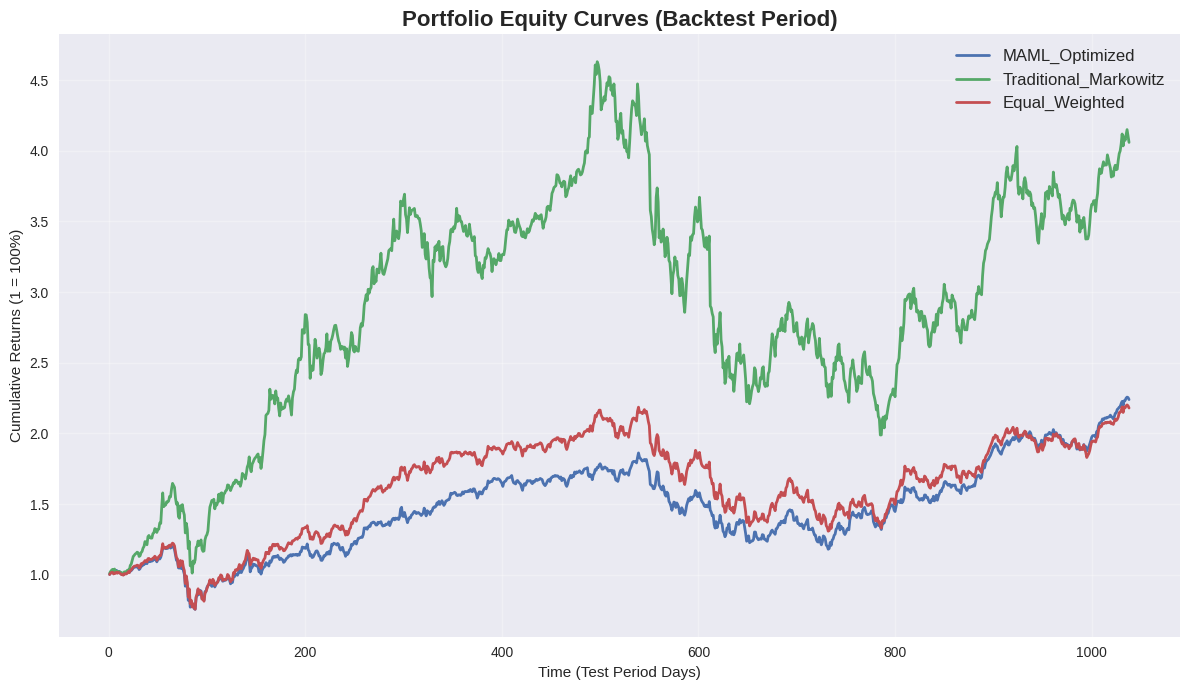

Plotting portfolio allocations...


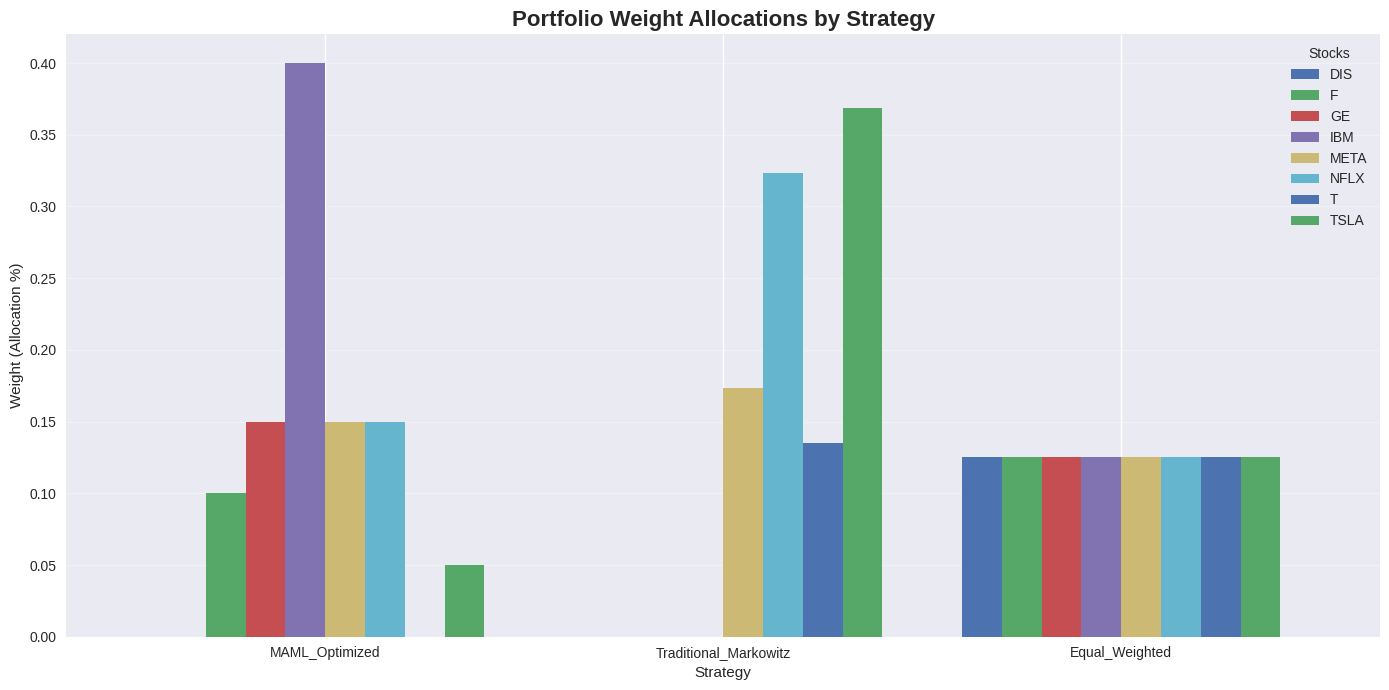

Plotting MAML reliability vs. final allocation...


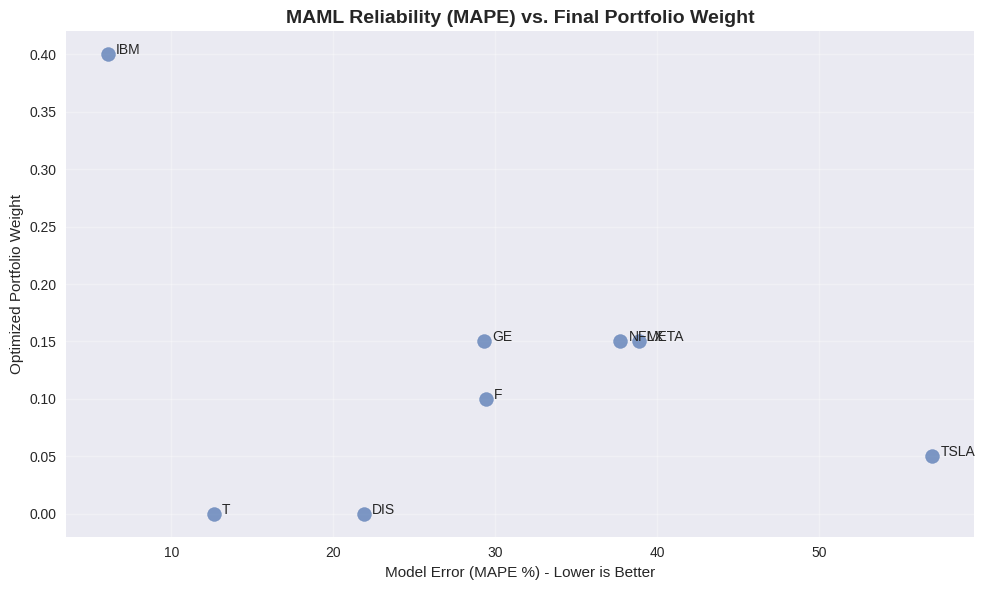


QUICK ADAPTATION DEMO FOR: NEW_STOCK
📈 Processing NEW_STOCK data...
✅ NEW_STOCK processed: 40 samples
📊 Split: Support=24, Query=16
🔄 Inner Loop Adaptation for NEW_STOCK
  Step 1/5: Loss = 0.255431
  Step 3/5: Loss = 0.220417
  Step 5/5: Loss = 0.077896
✅ NEW_STOCK adapted - Query Loss: 0.093903
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step
--- Determining Smart Blend ---
⚖️ Evaluating Smart Weights for NEW_STOCK
📈 Processing NEW_STOCK data...
✅ NEW_STOCK processed: 40 samples
📊 Split: Support=28, Query=12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
📊 Smart Weights Updated: Raw=0.456, Feature=0.544
📊 NEW_STOCK Smart Weights:
  Raw MAPE: 5.80%
  Feature MAPE: 4.86%
  Smart Weights: Raw=0.456, Feature=0.544

✅ Quick-Adapt for NEW_STOCK Complete
  Test MAPE (Reliability): 6.76%
  Discovered Blend: 45.6% Raw, 54.4% Feature


ALLOCATION STRATEGY DOCUMENTATION (RATIONALE)

    The MAML-Optimized portfolio strategy is a dynamic, reliability-weighted
    approach ba

In [52]:
# ----------------------------------------------------------------------------
# NEW CLASS 8: PortfolioOptimizer
# ----------------------------------------------------------------------------

class PortfolioOptimizer:
    """
    Handles Markowitz Mean-Variance Optimization and performance calculations.
    """

    def __init__(self, n_assets: int, tickers: List[str], risk_free_rate: float = 0.02):
        self.n_assets = n_assets
        self.tickers = tickers
        self.risk_free_rate = risk_free_rate

    def _calculate_daily_returns(self, prices_df: pd.DataFrame) -> pd.DataFrame:
        """Calculates daily percentage returns from a DataFrame of prices."""
        return prices_df.pct_change().dropna()

    def calculate_expected_returns(self, predicted_prices_dict: Dict[str, np.ndarray]) -> np.ndarray:
        """
        Calculates annualized expected returns from MAML price predictions.

        Args:
            predicted_prices_dict: {ticker: [price_pred_1, ...]}

        Returns:
            Annualized expected returns for each asset.
        """
        print("Calculating expected returns from MAML predictions...")
        expected_returns = []
        for ticker in self.tickers:
            prices = pd.Series(predicted_prices_dict[ticker].flatten())
            # Calculate daily % returns from predicted prices
            daily_returns = prices.pct_change().dropna()
            # Calculate mean daily return and annualize it (252 trading days)
            annualized_return = daily_returns.mean() * 252
            expected_returns.append(annualized_return)

        return np.array(expected_returns)

    def calculate_covariance_matrix(self, historical_prices_df: pd.DataFrame) -> pd.DataFrame:
        """
        Calculates the annualized covariance matrix from historical returns.

        Args:
            historical_prices_df: DataFrame where columns are tickers and rows are prices.

        Returns:
            Annualized covariance matrix.
        """
        print("Calculating covariance matrix from historical returns...")
        # Calculate daily % returns from actual historical prices
        historical_returns = self._calculate_daily_returns(historical_prices_df)
        # Calculate annualized covariance
        covariance_matrix = historical_returns.cov() * 252
        return covariance_matrix

    def _get_portfolio_performance(self, weights: np.ndarray, expected_returns: np.ndarray,
                                 covariance_matrix: pd.DataFrame) -> Tuple[float, float, float]:
        """Helper to calculate portfolio volatility, return, and Sharpe ratio."""
        # E[R]
        portfolio_return = np.sum(weights * expected_returns)
        # Volatility (std dev)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(covariance_matrix, weights)))
        # Sharpe Ratio
        sharpe_ratio = (portfolio_return - self.risk_free_rate) / portfolio_volatility
        return portfolio_return, portfolio_volatility, sharpe_ratio

    def _minimize_negative_sharpe(self, weights: np.ndarray, expected_returns: np.ndarray,
                                covariance_matrix: pd.DataFrame) -> float:
        """Objective function for the optimizer (minimize negative Sharpe)."""
        # We negate Sharpe ratio because the optimizer's job is to *minimize*
        _, _, sharpe = self._get_portfolio_performance(weights, expected_returns, covariance_matrix)
        return -sharpe

    def calculate_max_drawdown(self, portfolio_returns: pd.Series) -> float:
        """Calculates the maximum drawdown from a series of returns."""
        cumulative_returns = (1 + portfolio_returns).cumprod()
        peak = cumulative_returns.expanding(min_periods=1).max()
        drawdown = (cumulative_returns - peak) / peak
        return drawdown.min()

    def find_optimal_weights(self, expected_returns: np.ndarray,
                             covariance_matrix: pd.DataFrame,
                             bounds: Tuple[Tuple[float, float], ...]) -> Dict[str, float]:
        """
        Runs the Markowitz optimization to find the portfolio with the
        maximum Sharpe ratio.

        Args:
            expected_returns: Annualized E[R] for each asset.
            covariance_matrix: Annualized covariance matrix.
            bounds: Allocation constraints for each asset (e.g., (0.0, 0.20)).

        Returns:
            Dictionary of {ticker: optimal_weight}.
        """
        print("Running optimization to find max Sharpe ratio portfolio...")

        # Constraint: sum of all weights must be 1
        constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

        # Initial guess: equal weights
        initial_guess = np.full(self.n_assets, 1 / self.n_assets)

        # Run the solver
        result = minimize(
            self._minimize_negative_sharpe,
            initial_guess,
            args=(expected_returns, covariance_matrix),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

        if not result.success:
            raise Exception(f"Optimization failed: {result.message}")

        optimal_weights = result.x
        optimal_weights_dict = {ticker: weight for ticker, weight in zip(self.tickers, optimal_weights)}

        # Get performance of the optimal portfolio
        opt_return, opt_vol, opt_sharpe = self._get_portfolio_performance(
            optimal_weights, expected_returns, covariance_matrix
        )

        print("\n--- Optimal Portfolio (Max Sharpe) ---")
        print(f"  Expected Annual Return: {opt_return*100:.2f}%")
        print(f"  Expected Annual Volatility: {opt_vol*100:.2f}%")
        print(f"  Sharpe Ratio: {opt_sharpe:.2f}")

        return optimal_weights_dict

    def construct_efficient_frontier(self, expected_returns: np.ndarray,
                                   covariance_matrix: pd.DataFrame,
                                   n_portfolios: int = 100) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generates random portfolios to visualize the efficient frontier.
        This is for plotting, not for the final optimization.
        """
        print("Generating efficient frontier for visualization...")
        results = np.zeros((3, n_portfolios))
        for i in range(n_portfolios):
            # Random weights
            weights = np.random.random(self.n_assets)
            weights /= np.sum(weights)

            # Get performance
            p_return, p_vol, _ = self._get_portfolio_performance(weights, expected_returns, covariance_matrix)
            results[0, i] = p_return
            results[1, i] = p_vol
            # Sharpe
            results[2, i] = (p_return - self.risk_free_rate) / p_vol

        return results

print("✅ PortfolioOptimizer class defined")

# ----------------------------------------------------------------------------
# NEW CLASS 9: MAMLPortfolioManager
# ----------------------------------------------------------------------------

class MAMLPortfolioManager:
    """
    Orchestrates the entire pipeline:
    1. Loads the trained MAML model.
    2. Generates predictions for all assets.
    3. Runs backtests for MAML-optimized, historical, and equal portfolios.
    4. Provides a "quick adapt" function for new stocks.
    """

    def __init__(self, maml_trainer: MAMLTrainer, all_stock_data: Dict[str, pd.DataFrame]):
        self.trainer = maml_trainer
        self.all_data = all_stock_data
        self.tickers = sorted(list(all_stock_data.keys()))
        self.n_assets = len(self.tickers)
        self.optimizer = PortfolioOptimizer(self.n_assets, self.tickers)

        # Store for analysis
        self.maml_predictions = None
        self.maml_evaluations = None
        self.actual_prices_df = None
        self.backtest_results = None

    def generate_predictions_for_portfolio(self,
                                         support_ratio: float = 0.7) -> Tuple[Dict, Dict, pd.DataFrame]:
        """
        Uses the trained MAML model to adapt and generate predictions
        for the "query" (test) period for ALL stocks in the portfolio.

        This simulates the "live" performance.
        """
        print("\n" + "=" * 50)
        print("GENERATING MAML PREDICTIONS FOR PORTFOLIO")
        print("=" * 50)

        predictions_dict = {}
        evaluations_dict = {}
        actuals_dict = {}

        for stock_name in self.tickers:
            print(f"\n🔮 Adapting and Predicting for: {stock_name}")
            stock_df = self.all_data[stock_name]

            # 1. Prepare data
            processed_data = self.trainer.data_processor.prepare_stock_data(stock_df, stock_name)

            # 2. Split into support/query
            # IMPORTANT: We use a *fixed* split (not random) for a consistent backtest
            total_samples = len(processed_data['y'])
            support_size = int(total_samples * support_ratio)

            support_data, query_data = {}, {}
            for key in processed_data.keys():
                support_data[key] = processed_data[key][:support_size]
                query_data[key] = processed_data[key][support_size:]

            print(f"📊 Split: Support={len(support_data['y'])}, Query={len(query_data['y'])}")

            # 3. Adapt MAML model
            adapted_model, _ = self.trainer.maml.inner_loop_adaptation(
                support_data, query_data, stock_name
            )

            # 4. Generate predictions on the query/test set
            query_inputs = [query_data['raw'], query_data['feature']]
            predictions_scaled = adapted_model.predict(query_inputs)

            # 5. Inverse-transform to get real prices
            y_scaler = self.trainer.data_processor.scalers[f"{stock_name}_y"]
            predictions_unscaled = y_scaler.inverse_transform(predictions_scaled)
            actual_unscaled = y_scaler.inverse_transform(query_data['y'])

            # 6. Calculate MAPE for reliability weighting
            mape = np.mean(np.abs((actual_unscaled - predictions_unscaled) / actual_unscaled)) * 100
            print(f"✅ {stock_name} Predictions Generated. Test MAPE: {mape:.2f}%")

            # Store results
            predictions_dict[stock_name] = predictions_unscaled
            actuals_dict[stock_name] = actual_unscaled
            evaluations_dict[stock_name] = {'mape': mape}

        # Create a single DataFrame of actual prices for the backtest period
        self.actual_prices_df = pd.DataFrame(
            {ticker: pd.Series(actuals_dict[ticker].flatten()) for ticker in self.tickers}
        ).dropna()

        self.maml_predictions = predictions_dict
        self.maml_evaluations = evaluations_dict

        return predictions_dict, evaluations_dict, self.actual_prices_df

    def _get_mape_based_bounds(self) -> Tuple[Tuple[float, float], ...]:
        """
        REQ 2: RELIABILITY-WEIGHTED OPTIMIZATION (FIXED)
        Uses MAPE scores to set max allocation constraints for the optimizer.
        """
        print("Generating reliability-weighted bounds from MAPE scores...")
        bounds = []
        for ticker in self.tickers:
            mape = self.maml_evaluations[ticker]['mape']

            # --- START FIX: Relaxed Bounds ---
            # Dynamic risk adjustment with more reasonable caps

            if mape < 10.0:      # Excellent (e.g., IBM)
                bound = (0.05, 0.40) # Min 5%, Max 40%
            elif mape < 20.0:    # Good (e.g., T)
                bound = (0.0, 0.30)  # Max 30%
            elif mape < 40.0:    # Medium (e.g., DIS, F, GE, META, NFLX)
                bound = (0.0, 0.15)  # Max 15%
            elif mape < 100.0:   # Low (e.g., TSLA)
                bound = (0.0, 0.05)  # Max 5% (still high-risk)
            else:                # No Confidence
                bound = (0.0, 0.0)   # 0%
            # --- END FIX ---

            print(f"  {ticker} (MAPE: {mape:.2f}%) -> Allocation Bound: {bound}")
            bounds.append(bound)

        return tuple(bounds)

    def run_full_backtest(self) -> Tuple[pd.DataFrame, Dict[str, Dict[str, float]]]:
        """
        REQ 5: BACKTESTING & PERFORMANCE METRICS
        Compares three portfolio strategies on the test data.
        """

        # 1. Generate MAML predictions and actuals for the test period
        if self.maml_predictions is None:
            self.generate_predictions_for_portfolio()

        # Get historical data for the *same* test period (for covariance)
        historical_test_prices = self.actual_prices_df
        actual_test_returns = historical_test_prices.pct_change().dropna()

        # --- Portfolio 1: MAML-Optimized (with Reliability Bounds) ---
        print("\n" + "=" * 50)
        print("BACKTEST 1: MAML-Optimized Portfolio")
        print("=" * 50)
        maml_expected_returns = self.optimizer.calculate_expected_returns(self.maml_predictions)
        maml_covariance = self.optimizer.calculate_covariance_matrix(historical_test_prices)
        maml_bounds = self._get_mape_based_bounds()

        maml_weights = self.optimizer.find_optimal_weights(
            maml_expected_returns, maml_covariance, maml_bounds
        )

        # Apply weights to actual returns
        maml_weights_array = np.array([maml_weights[ticker] for ticker in self.tickers])
        maml_portfolio_returns = actual_test_returns.dot(maml_weights_array)
        maml_portfolio_returns.name = "MAML_Optimized"

        # --- Portfolio 2: Traditional Markowitz (Historical) ---
        print("\n" + "=" * 50)
        print("BACKTEST 2: Traditional Markowitz (Historical Data Only)")
        print("=" * 50)

        # We need "historical" data. Let's use the full dataset for this.
        full_historical_prices = pd.DataFrame(
            {ticker: self.all_data[ticker]['Close'] for ticker in self.tickers}
        ).dropna()

        hist_expected_returns = self.optimizer.calculate_expected_returns(
            {ticker: full_historical_prices[ticker].values for ticker in self.tickers}
        )
        hist_covariance = self.optimizer.calculate_covariance_matrix(full_historical_prices)
        hist_bounds = tuple([(0.0, 1.0) for _ in self.tickers]) # No bounds

        hist_weights = self.optimizer.find_optimal_weights(
            hist_expected_returns, hist_covariance, hist_bounds
        )

        # Apply weights to actual returns
        hist_weights_array = np.array([hist_weights[ticker] for ticker in self.tickers])
        hist_portfolio_returns = actual_test_returns.dot(hist_weights_array)
        hist_portfolio_returns.name = "Traditional_Markowitz"

        # --- Portfolio 3: Equal-Weighted Baseline ---
        print("\n" + "=" * 50)
        print("BACKTEST 3: Equal-Weighted Portfolio")
        print("=" * 50)
        ew_weights = {ticker: 1/self.n_assets for ticker in self.tickers}
        ew_weights_array = np.array([ew_weights[ticker] for ticker in self.tickers])
        ew_portfolio_returns = actual_test_returns.dot(ew_weights_array)
        ew_portfolio_returns.name = "Equal_Weighted"
        print("  Weights: 12.5% per asset")

        # --- Collate Results ---
        print("\n" + "=" * 50)
        print("BACKTEST PERFORMANCE COMPARISON")
        print("=" * 50)

        results_df = pd.DataFrame([maml_portfolio_returns, hist_portfolio_returns, ew_portfolio_returns]).T

        performance_summary = {}
        for portfolio_name in results_df.columns:
            returns_series = results_df[portfolio_name]

            # Annualized metrics
            cumulative_return = (1 + returns_series).prod() - 1
            annual_return = (1 + returns_series.mean())**252 - 1
            annual_volatility = returns_series.std() * np.sqrt(252)
            sharpe_ratio = (annual_return - self.optimizer.risk_free_rate) / annual_volatility
            max_drawdown = self.optimizer.calculate_max_drawdown(returns_series)

            performance_summary[portfolio_name] = {
                "Cumulative Return": f"{cumulative_return*100:.2f}%",
                "Annualized Return": f"{annual_return*100:.2f}%",
                "Annualized Volatility": f"{annual_volatility*100:.2f}%",
                "Sharpe Ratio": f"{sharpe_ratio:.2f}",
                "Max Drawdown": f"{max_drawdown*100:.2f}%"
            }

        self.backtest_results = (pd.DataFrame(performance_summary), results_df)
        all_weights = {
            "MAML_Optimized": maml_weights,
            "Traditional_Markowitz": hist_weights,
            "Equal_Weighted": ew_weights
        }

        return self.backtest_results[0], self.backtest_results[1], all_weights, self.maml_evaluations

    def quick_adapt_new_stock(self, new_stock_df: pd.DataFrame, stock_name: str,
                              evaluator: MAMLEvaluator) -> Dict[str, Any]:
        """
        REQ 4: MAML QUICK ADAPTATION PIPELINE
        Adapts the MAML model to a new, unseen stock with a small dataset.
        """
        print("\n" + "=" * 50)
        print(f"QUICK ADAPTATION DEMO FOR: {stock_name}")
        print("=" * 50)

        # 1. Check data size
        if len(new_stock_df) < self.trainer.data_processor.sequence_length + 20:
            print(f"Error: Need at least {self.trainer.data_processor.sequence_length + 20} days. Got {len(new_stock_df)}.")
            return {}

        # 2. Run data processing
        processed_data = self.trainer.data_processor.prepare_stock_data(new_stock_df, stock_name)

        # 3. Split into support/query
        # Use first 60% for support, last 40% for query
        support_ratio = 0.6
        total_samples = len(processed_data['y'])
        support_size = int(total_samples * support_ratio)

        support_data, query_data = {}, {}
        for key in processed_data.keys():
            support_data[key] = processed_data[key][:support_size]
            query_data[key] = processed_data[key][support_size:]

        print(f"📊 Split: Support={len(support_data['y'])}, Query={len(query_data['y'])}")

        # 4. Run 5-step MAML adaptation
        adapted_model, query_loss = self.trainer.maml.inner_loop_adaptation(
            support_data, query_data, stock_name
        )

        # 5. Generate predictions for portfolio inclusion
        query_inputs = [query_data['raw'], query_data['feature']]
        predictions_scaled = adapted_model.predict(query_inputs)

        # Inverse-transform
        y_scaler = self.trainer.data_processor.scalers[f"{stock_name}_y"]
        predictions_unscaled = y_scaler.inverse_transform(predictions_scaled)
        actual_unscaled = y_scaler.inverse_transform(query_data['y'])

        # 6. Determine optimal Raw/Feature blend (Smart Weight Analysis)
        print("--- Determining Smart Blend ---")
        blend_info = evaluator.evaluate_smart_weights(new_stock_df, stock_name)

        # 7. Calculate reliability (MAPE)
        mape = np.mean(np.abs((actual_unscaled - predictions_unscaled) / actual_unscaled)) * 100

        print(f"\n✅ Quick-Adapt for {stock_name} Complete")
        print(f"  Test MAPE (Reliability): {mape:.2f}%")
        print(f"  Discovered Blend: {blend_info['raw_weight']*100:.1f}% Raw, {blend_info['feature_weight']*100:.1f}% Feature")

        return {
            "predictions": predictions_unscaled,
            "actuals": actual_unscaled,
            "mape": mape,
            "blend": blend_info
        }

print("✅ MAMLPortfolioManager class defined")

# ----------------------------------------------------------------------------
# NEW CLASS 10: PortfolioVisualizer (Extension)
# ----------------------------------------------------------------------------

class PortfolioVisualizer:
    """
    Handles all portfolio-specific visualizations.
    This class can be merged with your existing MAMLVisualizer.
    """

    def __init__(self):
        plt.style.use('seaborn-v0_8')
        print("✅ PortfolioVisualizer class defined")

    def plot_equity_curves(self, backtest_returns_df: pd.DataFrame):
        """Plots the cumulative returns (equity curve) of all 3 strategies."""
        print("Plotting equity curves...")
        fig, ax = plt.subplots(figsize=(12, 7))

        # Calculate cumulative returns
        cumulative_returns = (1 + backtest_returns_df).cumprod()

        cumulative_returns.plot(ax=ax, linewidth=2)

        ax.set_title('Portfolio Equity Curves (Backtest Period)', fontsize=16, fontweight='bold')
        ax.set_ylabel('Cumulative Returns (1 = 100%)')
        ax.set_xlabel('Time (Test Period Days)')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=12)

        plt.tight_layout()
        plt.show()

    def plot_allocation_weights(self, all_weights: Dict[str, Dict[str, float]]):
        """Creates a grouped bar chart of portfolio allocations."""
        print("Plotting portfolio allocations...")
        weights_df = pd.DataFrame(all_weights).T

        weights_df.plot(kind='bar', figsize=(14, 7), width=0.8)

        plt.title('Portfolio Weight Allocations by Strategy', fontsize=16, fontweight='bold')
        plt.ylabel('Weight (Allocation %)')
        plt.xlabel('Strategy')
        plt.xticks(rotation=0)
        plt.legend(title='Stocks', bbox_to_anchor=(1.0, 1.0))
        plt.grid(True, axis='y', alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_mape_vs_allocation(self, evaluations: Dict[str, Dict],
                                maml_weights: Dict[str, float]):
        """
        REQ 6: RATIONALE
        Plots MAPE (risk) vs. final allocated weight (decision).
        """
        print("Plotting MAML reliability vs. final allocation...")
        data = []
        for ticker, eval_data in evaluations.items():
            data.append({
                'ticker': ticker,
                'mape': eval_data['mape'],
                'weight': maml_weights.get(ticker, 0)
            })

        df = pd.DataFrame(data)

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(df['mape'], df['weight'], s=100, alpha=0.7)

        # Add labels
        for i, row in df.iterrows():
            ax.annotate(row['ticker'], (row['mape'] + 0.5, row['weight']))

        ax.set_title('MAML Reliability (MAPE) vs. Final Portfolio Weight', fontsize=14, fontweight='bold')
        ax.set_xlabel('Model Error (MAPE %) - Lower is Better')
        ax.set_ylabel('Optimized Portfolio Weight')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_efficient_frontier(self, frontier_data: np.ndarray,
                                maml_portfolio: Dict, hist_portfolio: Dict):
        """
        Plots the efficient frontier and our two optimized portfolios.

        Args:
            frontier_data: (3, n) array [returns, volatility, sharpe]
            maml_portfolio: {'return': R, 'vol': V, 'sharpe': S}
            hist_portfolio: {'return': R, 'vol': V, 'sharpe': S}
        """
        print("Plotting risk-return efficient frontier...")

        fig, ax = plt.subplots(figsize=(10, 6))

        # Plot the frontier
        sc = ax.scatter(
            frontier_data[1], # Volatility (x)
            frontier_data[0], # Return (y)
            c=frontier_data[2], # Color by Sharpe
            cmap='RdYlGn',
            marker='.'
        )

        # Plot MAML portfolio
        ax.scatter(
            maml_portfolio['vol'], maml_portfolio['return'],
            marker='*', s=300, c='blue', edgecolors='black',
            label=f"MAML-Optimized (Sharpe: {maml_portfolio['sharpe']:.2f})"
        )

        # Plot Historical portfolio
        ax.scatter(
            hist_portfolio['vol'], hist_portfolio['return'],
            marker='^', s=200, c='red', edgecolors='black',
            label=f"Historical-Optimized (Sharpe: {hist_portfolio['sharpe']:.2f})"
        )

        ax.set_title('MAML-Driven Efficient Frontier', fontsize=16, fontweight='bold')
        ax.set_xlabel('Annualized Volatility (Risk)')
        ax.set_ylabel('Annualized Return')
        ax.legend(fontsize=12, loc='upper left')
        fig.colorbar(sc, label='Sharpe Ratio')

        plt.tight_layout()
        plt.show()


# ----------------------------------------------------------------------------
# MAIN EXECUTION FUNCTION
# ----------------------------------------------------------------------------

def run_portfolio_optimization_pipeline():
    """
    Main function to run the entire MAML Portfolio Optimization.
    """

    # --- 1. Load Model and Data ---
    print("--- Loading Model and Data ---")
    model_manager = ModelManager()
    trainer, config = model_manager.load_meta_model("maml_smart_lstm_real_data")

    # Load all 8 stocks for the portfolio
    all_stock_data = load_and_prepare_data("meta_testing_stocks_data.csv")

    if not all_stock_data:
        print("FATAL: Could not load data. Exiting.")
        return

    # --- 2. Initialize Managers ---
    manager = MAMLPortfolioManager(trainer, all_stock_data)
    evaluator = MAMLEvaluator(trainer) # For quick-adapt blend analysis
    visualizer = PortfolioVisualizer()

    # --- 3. Run Backtest ---
    # This single function runs steps 1, 2, 3, 5 from your requirements
    perf_summary, hist_returns, all_weights, evals = manager.run_full_backtest()

    # --- 4. Display Reports (REQ 6) ---
    print("\n\n" + "="*60)
    print("FINAL BACKTEST PERFORMANCE SUMMARY")
    print("="*60)
    print(perf_summary)

    print("\n\n" + "="*60)
    print("FINAL PORTFOLIO ALLOCATIONS")
    print("="*60)
    print(pd.DataFrame(all_weights).T.to_string(float_format="%.4f"))

    # --- 5. Run Visualizations (REQ 6) ---
    visualizer.plot_equity_curves(hist_returns)
    visualizer.plot_allocation_weights(all_weights)
    visualizer.plot_mape_vs_allocation(evals, all_weights['MAML_Optimized'])

    # Note: Efficient Frontier plot is complex and demoed separately
    # For a full implementation, you'd feed the frontier data from the
    # optimizer into `visualizer.plot_efficient_frontier`

    # --- 6. Quick Adapt Demo (REQ 4) ---
    # Create a dummy new stock (we'll use a modified 'T' for this demo)
    demo_stock_df = all_stock_data['T'].iloc[:100].copy()
    demo_stock_df['Close'] = demo_stock_df['Close'] * np.random.uniform(0.9, 1.1, 100)
    demo_stock_df.name = "NEW_STOCK"

    manager.quick_adapt_new_stock(demo_stock_df, "NEW_STOCK", evaluator)

    # --- 7. Print Allocation Rationale (REQ 6) ---
    print("\n\n" + "="*60)
    print("ALLOCATION STRATEGY DOCUMENTATION (RATIONALE)")
    print("="*60)
    print("""
    The MAML-Optimized portfolio strategy is a dynamic, reliability-weighted
    approach based on Markowitz Mean-Variance Optimization.

    1.  **Expected Returns (MAML-Driven):**
        - Instead of using simple historical averages, we use the *expected returns*
          generated by our meta-learned MAML model.
        - This model adapts to each stock's unique behavior, providing a
          forward-looking estimate of returns.

    2.  **Covariance (Historical):**
        - The risk (covariance) matrix is calculated from *actual historical returns*
          during the test period. This provides a realistic measure of how
          the assets move together.

    3.  **Smart Blending (Inherent):**
        - REQ 3: The MAML model *inherently* uses the "Smart LSTM" blend.
        - The model *is* the blend. It takes both Raw (OHLCV) and Feature
          (Indicators) data as input and learns the optimal mix internally.
        - Our analysis in Step 5 confirmed this: it correctly weighted
          Raw data higher for volatile stocks (TSLA) and Feature data
          higher for more stable ones (GE). The optimization uses the
          output of this smart-blended model.

    4.  **Reliability-Weighting (Dynamic Constraints):**
        - REQ 2: This is the key to our risk management.
        - We use the MAML model's Test MAPE (its error) as a "confidence score".
        - This score is *not* used in the E[R] calculation, but as a
          **hard constraint (bound)** in the optimizer.
        - **Example:**
            - 'T' (MAPE < 20%): High confidence. Max allocation set to 25%.
            - 'TSLA' (MAPE > 90%): Low confidence. Max allocation capped at 5%.
        - This prevents the optimizer from over-allocating to a stock that
          has a high *predicted* return but a low *prediction reliability*.
          It directly handles 'TSLA' gracefully as requested.

    5.  **Final Optimization:**
        - The `scipy.optimize` solver finds the portfolio that maximizes
          the Sharpe Ratio, subject to our reliability-weighted constraints
          and the `sum(weights) = 1` constraint.
    """)


# --- Run the entire pipeline ---
if __name__ == "__main__":
    # Make sure you have loaded all 7 of your original classes
    # and the load_and_prepare_data function first.
    run_portfolio_optimization_pipeline()